In [1]:
import BECancerResistome
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, f1_score
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.metrics import precision_recall_curve, average_precision_score
import time
import shap
import optuna
import umap

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Load Data

In [3]:
annotated_control_df = pd.read_csv("data/8_Cellular_Drug_Context/zscores-unambiguous-VEPannotated-processed-protvar-cellular_drug_context-control.csv")

## Select Dataset for Prediction

In [4]:
annotated_variants_df = annotated_control_df

In [5]:
annotated_variants_df.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,Target Transcript ID,uniprot_accession,RefSeq match transcript (MANE Select),Amino Acid Edits,aa_change,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,EVE_SCORE,AlphaMissense_score,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,Gene_expression_voom,foldx_ddg,alphafold_plddt,pocket_id,min_pocket_buriedness,pocket_plddt_mean,pocket_score_combined_scaled,CRISPR_essentiality_score,is_in_interface,interface_count,protein_abundance_zscore,gene_cn_total,gene_cn_category_enc,gene_cn_category_Amplification,gene_cn_category_Gain,gene_cn_category_Loss,gene_cn_category_Neutral,lnIC50,drug_target_gene_distance,is_drug_target
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.274277,non-hit,EG,ENST00000357387.8,Q6R327,NM_152756.5,His1109Tyr,H1109Y,3.0,2.0,1.0,1.0,0.000,0.214,0.463040,NaN,0.0685,-0.402171,0.970933,0.045001,-4.388,5.314964,0.516773,5.75,5.75,0.917608,0.44121,0.445060,0.093490,0.179100,-1.0259,0.000785,0.345,-0.22,1.0,0.094767,226.0,0.800526,NaN,1.000,5.938,20.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.305,NaN,NaN,5.531900,NaN,NaN,NaN,NaN,NaN,NaN,-0.243777,0.0,0.0,0.36936,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,2.0,0.0
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,PIC,0.399691,non-hit,EG,ENST00000369535.5,P01111,NM_002524.5,Leu171Phe,L171F,3.0,2.0,1.0,0.1,NaN,0.141,0.413488,NaN,0.1149,-0.222424,0.993713,0.120039,-5.943,3.683551,0.294249,5.86,5.86,0.865513,0.74516,1.008632,0.619943,0.190982,-0.9613,0.907693,1.385,-1.28,1.0,0.072730,819.0,0.580949,0.628916,1.000,4.055,23.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.550,NaN,NaN,6.702081,-0.239753,88.23,NaN,NaN,NaN,NaN,-0.178272,0.0,0.0,-0.61887,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,1.0,0.0
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,PIC,0.399178,non-hit,EG,ENST00000674063.1,P42338,NM_006219.3,Thr930Ile,T930I,3.0,2.0,NaN,0.0,0.862,NaN,0.373381,NaN,NaN,-0.058094,0.998396,0.879846,-10.191,4.891242,0.469329,5.63,3.78,NaN,0.73854,NaN,NaN,NaN,0.6434,0.529280,3.705,NaN,0.0,0.365695,856.0,0.310513,NaN,0.998,2.094,25.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.319,NaN,NaN,5.786491,-0.070749,91.70,10.0,0.848224,90.132188,949.413840,-0.290119,0.0,0.0,0.05922,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,0.0,1.0
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,PIC,-0.801011,non-hit,EG,ENST00000275493.7,P00533,NM_005228.5,Leu480Leu,L480L,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.051,NaN,NaN,NaN,21.0,-44.0,-45.0,45.0,0.0,0.0,0.0,0.0,NaN,0.475,-0.01879,NaN,3.875409,NaN,NaN,6.0,0.808046,94.882812,975.087068,-0.075387,0.0,0.0,-0.74347,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,1.0,0.0
4,AAAAAATCCAGCGTCTAAGC,CBE,MYC,A375,PIC,-0.379377,non-hit,EG,ENST00000621592.8,P01106,NM_002467.6,Asp2Asn,D2N,3.0,2.0,1.0,0.0,0.199,NaN,0.453567,NaN,0.1399,-0.438067,0.984375,NaN,NaN,1.792897,-0.197017,4.31,2.43,0.397160,NaN,NaN,0.733174,0.215208,-0.7405,0.036037,NaN,NaN,1.0,NaN,951.0,0.226082,0.128201,1.000,1.507,22.100,NaN,NaN,NaN,16.0,-14.0,10.0,26.0,0.0,0.0,0.0,0.0,1.0,0.128,NaN,NaN,3.687539,-0.237760,55.70,NaN,NaN,NaN,NaN,-1.698486,0.0,0.0,NaN,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,2.0,0.0


In [6]:
annotated_variants_df['Cell_Line'].unique()

array(['A375', 'HT29', 'H23', 'PC9', 'MHHES1'], dtype=object)

# Classification

## Encode Labels

In [7]:
#Define Sensitivity, Neutral and Resistance classes
annotated_variants_df['Class'] = annotated_variants_df['Hit_class'].replace({'negative': 'Sensitivity', 'non-hit': 'Neutral', 'positive': 'Resistance'})
annotated_variants_df.drop(columns=['Hit_class'], inplace=True)

#Encode Classes
le = LabelEncoder()
annotated_variants_df['Class_encoded'] = le.fit_transform(annotated_variants_df['Class'])

In [8]:
# Check encoding mapping
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label mapping:", label_mapping)

Label mapping: {'Neutral': np.int64(0), 'Resistance': np.int64(1), 'Sensitivity': np.int64(2)}


In [9]:
annotated_variants_df['Class_encoded'].value_counts()

Class_encoded
0    145210
1      1134
2       741
Name: count, dtype: int64

In [10]:
annotated_variants_df['Class'].value_counts()

Class
Neutral        145210
Resistance       1134
Sensitivity       741
Name: count, dtype: int64

## Split MC and EG

In [11]:
#Keep only rows with EG drugs, cell lines and drop 'MC' source
annotated_variants_EG = annotated_variants_df[annotated_variants_df['Drug'].isin(['PIC', 'SCH', 'LIN'])]
annotated_variants_EG = annotated_variants_EG[annotated_variants_EG['Cell_Line'].isin(['HT29', 'A375'])]
annotated_variants_EG = annotated_variants_EG[annotated_variants_EG['Source'] != 'MC']

In [12]:
annotated_variants_MC = annotated_variants_df[annotated_variants_df['Drug'].isin(['PIC', 'ADAG', 'SOTOR', 'DEB-CET', 'TRAM', 'GEFIT', 'OSIM', 'NIRAP', 'OLAP'])]
annotated_variants_MC = annotated_variants_MC[annotated_variants_MC['Cell_Line'].isin(['HT29', 'H23', 'PC9', 'MHHES1'])]
annotated_variants_MC = annotated_variants_MC[annotated_variants_MC['Source'] != 'EG']

In [13]:
len(annotated_variants_EG), len(annotated_variants_MC)

(84024, 63061)

In [14]:
annotated_variants_MC['Guide'].nunique(), annotated_variants_EG['Guide'].nunique()

(6373, 14004)

In [15]:
len(annotated_variants_df)

147085

In [16]:
annotated_variants_MC.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Source,Target Transcript ID,uniprot_accession,RefSeq match transcript (MANE Select),Amino Acid Edits,aa_change,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,EVE_SCORE,AlphaMissense_score,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,Gene_expression_voom,foldx_ddg,alphafold_plddt,pocket_id,min_pocket_buriedness,pocket_plddt_mean,pocket_score_combined_scaled,CRISPR_essentiality_score,is_in_interface,interface_count,protein_abundance_zscore,gene_cn_total,gene_cn_category_enc,gene_cn_category_Amplification,gene_cn_category_Gain,gene_cn_category_Loss,gene_cn_category_Neutral,lnIC50,drug_target_gene_distance,is_drug_target,Class,Class_encoded
84024,AAAAAACTGTTTGGGACCTC,CBE,EGFR,H23,ADAG,-0.493390,MC,ENST00000275493.7,P00533,NM_005228.5,Leu480Leu,L480L,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.051,NaN,NaN,NaN,21.0,-44.0,-45.0,45.0,0.00,0.0,0.0,0.00,NaN,0.475,-0.01879,NaN,6.824679,NaN,NaN,6.0,0.808046,94.882812,975.087068,0.100856,0.0,0.0,0.09443,3.0,2.0,0.0,0.0,0.0,1.0,NaN,1.0,0.0,Neutral,0
84025,AAAAAATCCAGCGTCTAAGC,CBE,MYC,H23,ADAG,-0.373472,MC,ENST00000621592.8,P01106,NM_002467.6,Asp2Asn,D2N,3.0,2.0,1.0,0.0,0.199,NaN,0.453567,NaN,0.1399,-0.438067,0.984375,NaN,NaN,1.792897,-0.197017,4.31,2.43,0.39716,NaN,NaN,0.733174,0.215208,-0.7405,0.036037,NaN,NaN,1.0,NaN,951.0,0.226082,0.128201,1.0,1.507,22.100,NaN,NaN,NaN,16.0,-14.0,10.0,26.0,0.00,0.0,0.0,0.00,1.0,0.128,NaN,NaN,7.207870,-0.23776,55.7,NaN,NaN,NaN,NaN,-2.114067,0.0,0.0,1.89295,2.0,1.0,0.0,0.0,1.0,0.0,NaN,2.0,0.0,Neutral,0
84026,AAAAACAATTGGGAAGATCG,CBE,PARP2,H23,ADAG,0.914713,MC,ENST00000429687.8,Q9UGN5,NM_001042618.2,Asn173Asn,N173N,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.333,NaN,NaN,NaN,-46.0,-21.0,-22.0,30.0,0.01,0.0,0.0,0.00,NaN,0.998,NaN,NaN,5.939250,NaN,NaN,NaN,NaN,NaN,NaN,-0.105556,NaN,NaN,0.39347,3.0,2.0,0.0,0.0,0.0,1.0,NaN,3.0,0.0,Neutral,0
84027,AAAAACTGCACCTCCATCAG,CBE,EGFR,H23,ADAG,-0.677259,MC,ENST00000275493.7,P00533,NM_005228.5,Asn361Asn,N361N,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.656,NaN,NaN,NaN,15.0,-43.0,-29.0,50.0,0.00,0.0,0.0,0.05,NaN,0.475,0.00000,NaN,6.824679,NaN,NaN,8.0,0.761069,81.607353,932.447796,0.100856,0.0,0.0,0.09443,3.0,2.0,0.0,0.0,0.0,1.0,NaN,1.0,0.0,Neutral,0
84028,AAAAACTGTTTGGGACCTCC,CBE,EGFR,H23,ADAG,0.418113,MC,ENST00000275493.7,P00533,NM_005228.5,Leu480Leu,L480L,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.051,NaN,NaN,NaN,21.0,-44.0,-45.0,45.0,0.00,0.0,0.0,0.00,NaN,0.475,-0.01879,NaN,6.824679,NaN,NaN,6.0,0.808046,94.882812,975.087068,0.100856,0.0,0.0,0.09443,3.0,2.0,0.0,0.0,0.0,1.0,NaN,1.0,0.0,Neutral,0


In [17]:
annotated_variants_MC['Editor'].value_counts()

Editor
ABE    37098
CBE    25963
Name: count, dtype: int64

### Filters 

In [18]:
annotated_variants_MC_cbe = annotated_variants_MC[annotated_variants_MC['Editor'] == 'CBE']
annotated_variants_MC_abe = annotated_variants_MC[annotated_variants_MC['Editor'] == 'ABE']

In [19]:
annotated_variants_MC['Drug'].unique()

array(['ADAG', 'SOTOR', 'DEB-CET', 'PIC', 'TRAM', 'GEFIT', 'OSIM',
       'NIRAP', 'OLAP'], dtype=object)

In [20]:
# Filter out rows with drug 'DEB-CET'
annotated_variants_MC_no_deb_cet = annotated_variants_MC_cbe[annotated_variants_MC_cbe['Drug'] != 'DEB-CET']
annotated_variants_MC_no_deb_cet_olap_nirap = annotated_variants_MC_no_deb_cet[~annotated_variants_MC_no_deb_cet['Drug'].isin(['OLAP', 'NIRAP'])]

In [21]:
#Filter out PC9
annotated_variants_MC_no_deb_cet_olap_nirap_pc9 = annotated_variants_MC_no_deb_cet_olap_nirap[annotated_variants_MC_no_deb_cet_olap_nirap['Cell_Line'] != 'PC9']

In [21]:
#Filter for HT29 cell line
annotated_variants_MC_ht29 = annotated_variants_MC_no_deb_cet_olap_nirap[annotated_variants_MC_no_deb_cet_olap_nirap['Cell_Line'] == 'HT29']

In [22]:
annotated_variants_MC_ht29['Drug'].value_counts()

Drug
PIC     3709
TRAM    3709
Name: count, dtype: int64

In [23]:
annotated_variants_MC_ht29['Guide'].nunique()

3709

In [25]:
annotated_variants_MC_ht29['Class'].value_counts()

Class
Neutral        7383
Sensitivity      21
Resistance       14
Name: count, dtype: int64

In [337]:
annotated_variants_MC_ht29['Editor'].value_counts()

Editor
CBE    7418
Name: count, dtype: int64

In [338]:
annotated_variants_MC_ht29['Cell_Line'].value_counts()

Cell_Line
HT29    7418
Name: count, dtype: int64

In [310]:
annotated_variants_MC_no_deb_cet_olap_nirap_pc9['Drug'].value_counts()

Drug
ADAG     7831
SOTOR    7831
PIC      7831
TRAM     7831
Name: count, dtype: int64

In [245]:
annotated_variants_MC['Cell_Line'].value_counts()

Cell_Line
HT29      23493
H23       15662
PC9       15662
MHHES1     8244
Name: count, dtype: int64

In [247]:
annotated_variants_MC[annotated_variants_MC['Cell_Line'] == 'MHHES1']['Drug'].value_counts()

Drug
NIRAP    4122
OLAP     4122
Name: count, dtype: int64

## Handle Class Imbalance

In [24]:
class_df = annotated_variants_MC_ht29

In [25]:
class_counts = class_df['Class'].value_counts()
class_proportions= class_df['Class'].value_counts(normalize=True)

print("Class counts:\n", class_counts)
print("\nClass percentage:\n", (class_proportions*100).round(2))

Class counts:
 Class
Neutral        7383
Sensitivity      21
Resistance       14
Name: count, dtype: int64

Class percentage:
 Class
Neutral        99.53
Sensitivity     0.28
Resistance      0.19
Name: proportion, dtype: float64


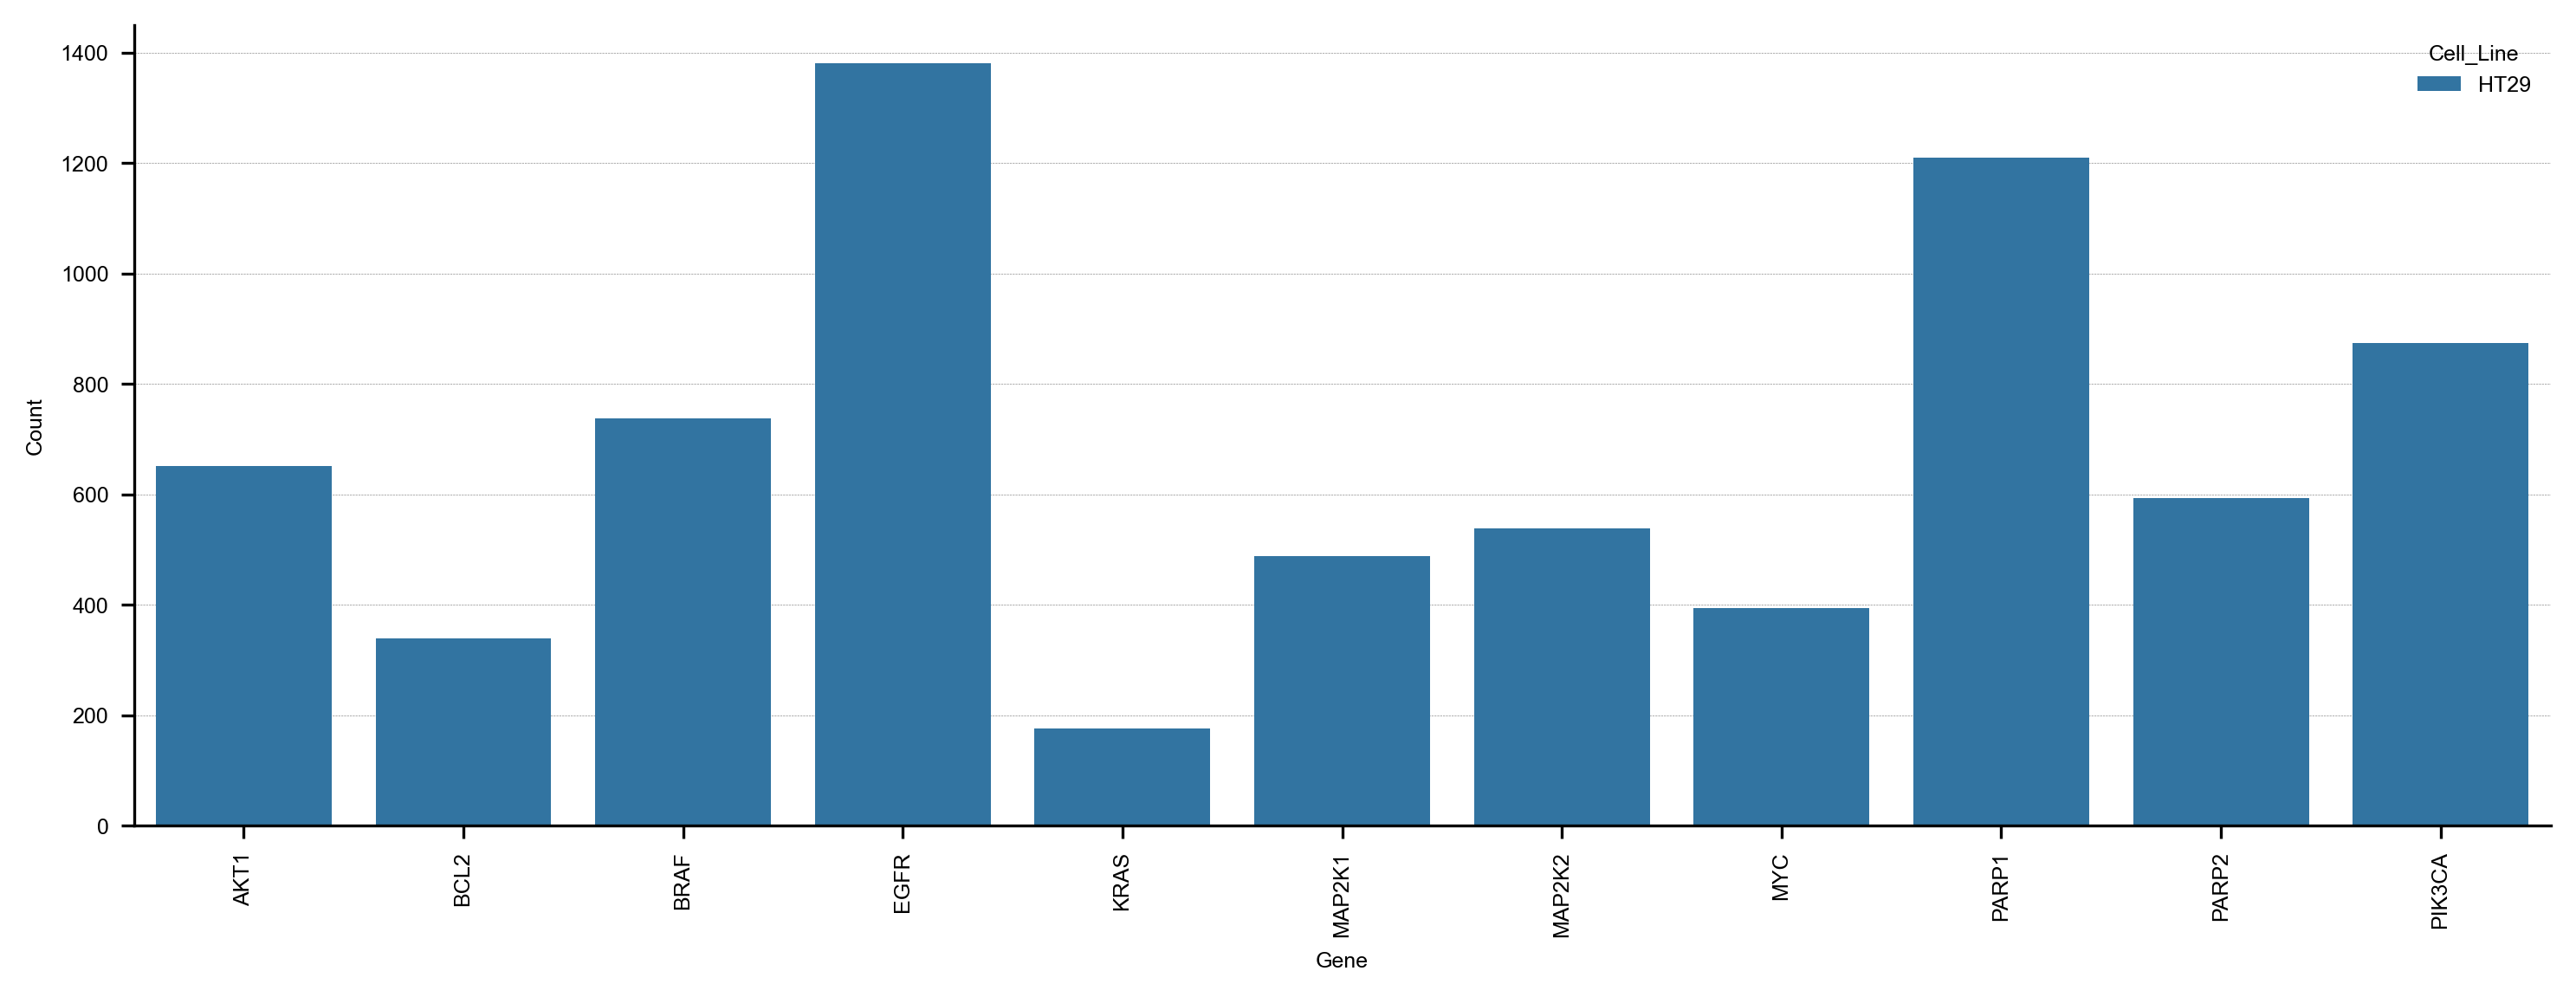

In [26]:
counts_before_DS = (
    class_df
    .groupby(["Cell_Line", "Gene", "Class"])
    .size()
    .reset_index(name="Count")
)

counts_non_hits_before_DS = counts_before_DS[counts_before_DS["Class"] == "Neutral"]

plt.figure(figsize=(12,4))
sns.barplot(
    data=counts_non_hits_before_DS,
    x="Gene", y="Count", hue='Cell_Line', errorbar=None
)

plt.xticks(rotation=90)
plt.show()

In [27]:
def stratified_downsampling(df, class_col, random_state=None):
    #Infer majority class + target size (length of the second largest class)
    class_counts = df[class_col].value_counts()
    majority_class = class_counts.idxmax()
    target_size = class_counts.nlargest(2).iloc[-1]

    #Separate majority class and other classes
    major_df = df[df[class_col] == majority_class]
    other_df = df[df[class_col] != majority_class]

    # If majority already not bigger than target, nothing to do
    if len(major_df) <= target_size:
        return df.copy()
    
    #Compute distribution of the majority df across Cell_Line and Gene
    major_distribution = (
        major_df
        .groupby(['Cell_Line', 'Gene'])
        .size()
        .reset_index(name='Count')
    )

    # Calculate proportions
    major_distribution['Proportion'] = major_distribution['Count'] / major_distribution['Count'].sum()

    # Determine number of samples to select from each Cell_Line × Gene group
    major_distribution['Target'] = np.floor(major_distribution['Proportion'] * target_size).astype(int)

    # Adjust target to ensure total matches target size 
    # i.e., distribute the remaining samples to the groups with the largest fractional remainders
    difference = target_size - major_distribution['Target'].sum()
    if difference > 0:
        fractional_parts = major_distribution['Proportion'] * target_size - major_distribution['Target']
        top_idx = fractional_parts.nlargest(difference).index
        major_distribution.loc[top_idx, 'Target'] += 1

    #Perform stratified downsampling
    downsampled_major_dfs= []
    for _, row in major_distribution.iterrows():
        cell_line = row['Cell_Line']
        gene = row['Gene']
        target = row['Target']

        subset = major_df[(major_df['Cell_Line'] == cell_line) & (major_df['Gene'] == gene)]

        if target > 0:
            n_sampled = min(target, len(subset)) # in case it is a very small group - but can lead to less samples than target_size overall
            downsampled_major_dfs.append(subset.sample(n=n_sampled, random_state=random_state))
    
    #Keep the indices until after the Top up step
    downsampled_majority_class_df = pd.concat(downsampled_major_dfs, axis=0)

    #Top up if needed (if very small groups caused total to be less than target_size)
    current_size = len(downsampled_majority_class_df)
    missing = target_size - current_size

    if missing>0: #ask supervisor if this is really needed
        remaining_samples = major_df.loc[~major_df.index.isin(downsampled_majority_class_df.index)]
        assert not remaining_samples.empty, ("Logic error: remaining_samples is empty but target_size not reached.")
        extra_n= min(missing, len(remaining_samples))
        extra_samples = remaining_samples.sample(n=extra_n, random_state=random_state)

        #Random subsample from the remaining samples now
        downsampled_majority_class_df = pd.concat([downsampled_majority_class_df, extra_samples], axis=0)

    # Reset index only at the end
    downsampled_majority_class_df = downsampled_majority_class_df.reset_index(drop=True)

    #Combine downsampled majority class with other classes
    balanced_df = pd.concat([downsampled_majority_class_df, other_df], ignore_index=True)

    return balanced_df

In [34]:
#Balanced Dataset
annotated_variants_MC_balanced = stratified_downsampling(annotated_variants_MC_ht29 ,class_col='Class', random_state=1)
annotated_variants_EG_balanced = stratified_downsampling(annotated_variants_EG ,class_col='Class', random_state=1)

In [29]:
print("Final class counts:")
print(annotated_variants_MC_balanced["Class"].value_counts())

Final class counts:
Class
Neutral        21
Sensitivity    21
Resistance     14
Name: count, dtype: int64


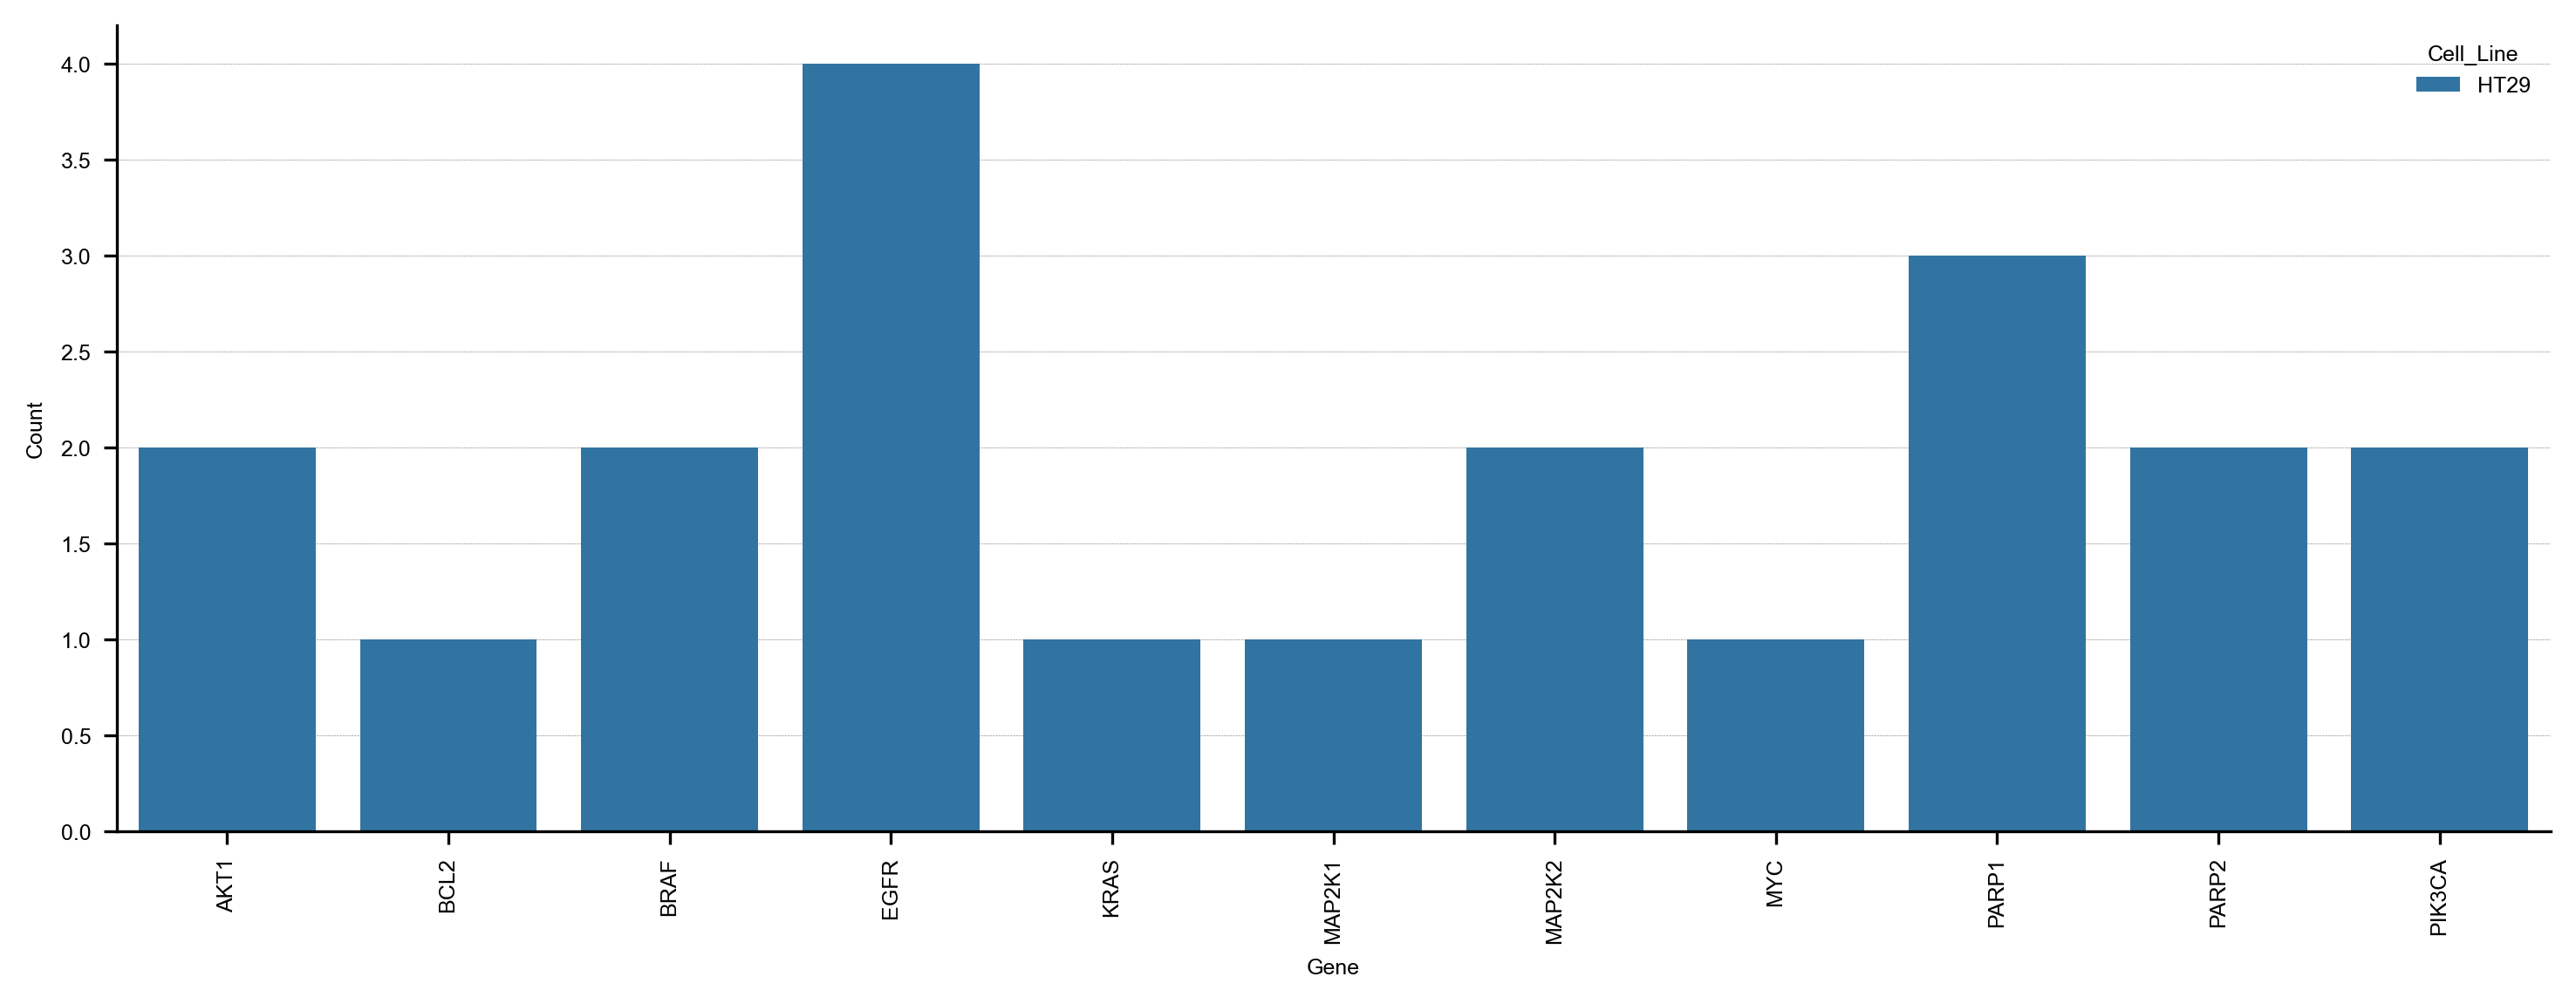

In [30]:
#Check distribution of non-hits after downsampling

counts_after_DS = (
    annotated_variants_MC_balanced
    .groupby(["Cell_Line", "Gene", "Class"])
    .size()
    .reset_index(name="Count")
)

counts_non_hits_after_DS = counts_after_DS[counts_after_DS["Class"] == "Neutral"]

plt.figure(figsize=(12,4))
sns.barplot(
    data=counts_non_hits_after_DS,
    x="Gene", y="Count", hue="Cell_Line", errorbar=None
)

plt.xticks(rotation=90)
plt.show()

In [47]:
# Compute proportions within each group (Cell_Line × Gene)
prop_before = counts_non_hits_before_DS.copy()
prop_before["Proportion_before_DS"] = round(prop_before["Count"] / prop_before["Count"].sum(),4)
prop_before = prop_before[["Cell_Line", "Gene", "Proportion_before_DS"]]

prop_after = counts_non_hits_after_DS.copy()
prop_after["Proportion_after_DS"] = round(prop_after["Count"] / prop_after["Count"].sum(), 4)
prop_after = prop_after[["Cell_Line", "Gene", "Proportion_after_DS"]]


prop_compare = pd.merge(prop_before, prop_after,
                        on=["Cell_Line", "Gene"], how="inner")

# Correlation of proportions
corr = prop_compare["Proportion_before_DS"].corr(prop_compare["Proportion_after_DS"])

print("Correlation of per-group proportions (before vs after downsampling):", round(corr, 4))
print("\nProportion comparison (first 10 rows):")
print(prop_compare.head(10))

Correlation of per-group proportions (before vs after downsampling): 0.9983

Proportion comparison (first 10 rows):
  Cell_Line    Gene  Proportion_before_DS  Proportion_after_DS
0       H23    AKT1                0.0248               0.0260
1       H23    BCL2                0.0124               0.0116
2       H23    BRAF                0.0235               0.0231
3       H23    EGFR                0.0482               0.0491
4       H23    KRAS                0.0045               0.0058
5       H23  MAP2K1                0.0155               0.0145
6       H23  MAP2K2                0.0196               0.0202
7       H23     MYC                0.0140               0.0145
8       H23   PARP1                0.0412               0.0405
9       H23   PARP2                0.0187               0.0202


# Modeling

In [31]:
#Define meta data columns to drop
meta_cols=[
    'Guide', 'Editor', 'Gene', 'Cell_Line', 'Drug', 'zscore', 'Source', 'Target Transcript ID', 'uniprot_accession',
    'RefSeq match transcript (MANE Select)', 'Amino Acid Edits', 'aa_change', 'pocket_id', 'Class'
]

In [32]:
def train_test_once_no_cv(train_df, test_df, model, meta_cols, le, stratified_downsampling, class_col, random_state_for_downsampling):
    
    #Downsample training set
    train_df_balanced = stratified_downsampling(train_df, class_col = class_col, random_state=random_state_for_downsampling)
    test_df_balanced = stratified_downsampling(test_df, class_col = class_col, random_state=1)

    #Without downsampling for this version
    #train_df_balanced = train_df.copy()

    #Print train class distribution after downsampling
    print("Class distribution after downsampling:")
    print(train_df_balanced['Class'].value_counts())

    #Split features and labels
    X_train = train_df_balanced.drop(columns="Class_encoded")
    y_train = train_df_balanced["Class_encoded"]

    X_test = test_df_balanced.drop(columns="Class_encoded")
    y_test = test_df_balanced["Class_encoded"]

    #Print test class distribution
    print("Test set class distribution:")
    print(X_test['Class'].value_counts())

    #Store meta data for test set
    meta_X_test = X_test[meta_cols].copy()
    meta_X_test['original_index'] = X_test.index

    X_train = X_train.drop(columns=meta_cols)
    X_test  = X_test.drop(columns=meta_cols)

    #Train model
    model.fit(X_train, y_train)

    #Predict on test set
    y_pred = model.predict(X_test)
    probs = model.predict_proba(X_test)

    #Metrics
    class_names = list(le.classes_)
    metrics = {}

    report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)

    metrics['accuracy'] = report['accuracy']

    for avg_key in ['macro avg', 'weighted avg']:
        metrics[f'precision_{avg_key}'] = report[avg_key]['precision']
        metrics[f'recall_{avg_key}'] = report[avg_key]['recall']
        metrics[f'f1_{avg_key}'] = report[avg_key]['f1-score']

    for cname in class_names:
        metrics[f'precision_{cname}'] = report[cname]['precision']
        metrics[f'recall_{cname}'] = report[cname]['recall']
        metrics[f'f1_{cname}'] = report[cname]['f1-score']

    
    n_classes = len(class_names)

    #ROC AUC
    if n_classes == 2:
        # Binary case
        metrics['roc_auc'] = roc_auc_score(y_test, probs[:, 1])
    else:
        # Multiclass 
        metrics['roc_auc_weighted'] = roc_auc_score(y_test, probs, multi_class='ovr', average='weighted')
        metrics['roc_auc_macro'] = roc_auc_score(y_test, probs, multi_class='ovr', average='macro')

    #PR AUC
    if n_classes == 2:
        # Binary case
        metrics['pr_auc'] = average_precision_score(y_test, probs[:, 1])
    else:
        # Multiclass 
        metrics['pr_auc_weighted'] = average_precision_score(y_test, probs, average='weighted')
        metrics['pr_auc_macro'] = average_precision_score(y_test, probs, average='macro')

    #Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(class_names)))

    return metrics, cm, y_test.values, y_pred, probs

### Define Model 

In [33]:
optimized_params = {'n_estimators': 473,
                    'max_depth': 8,
                    'learning_rate': 0.014757846958987166,
                    'subsample': 0.9074779169306355,
                    'colsample_bytree': 0.5480484893807359,
                    'min_child_weight': 1,
                    'reg_alpha': 0.0004937375718649116,
                    'reg_lambda': 0.000319094062330884,
                    'gamma': 0.6244886434704836}

#Define optimized XGBClassifier with Optuna parameters  
xgb_classifier_optimized = XGBClassifier(
    **optimized_params                   
)

### Run Model

In [39]:
# Run multiple times to get average performance across different downsamplings
n_runs=10

all_metrics, all_cms = [], []
all_y_true_runs, all_y_pred_runs, all_probs_runs = [], [], []

for i in range(n_runs):
    print(f"\n--- Run {i+1}/{n_runs} ---")

    metrics, cm, y_true, y_pred, probs = train_test_once_no_cv(
        train_df=annotated_variants_EG,
        test_df=annotated_variants_MC_ht29,
        model=xgb_classifier_optimized,
        meta_cols=meta_cols,
        le=le,
        stratified_downsampling=stratified_downsampling,
        class_col="Class",
        random_state_for_downsampling=i
    )

    all_metrics.append(metrics)
    all_cms.append(cm)
    all_y_true_runs.append(y_true)
    all_y_pred_runs.append(y_pred)
    all_probs_runs.append(probs)

    print("Metrics:", metrics)
    print("Confusion Matrix:\n", cm)

# === Aggregate metrics across runs ===
metrics_df = pd.DataFrame(all_metrics)
metrics_mean = metrics_df.mean()
metrics_std = metrics_df.std()

cm_mean = np.mean(np.array(all_cms, dtype=float), axis=0)
cm_std  = np.std(np.array(all_cms, dtype=float), axis=0)

desired_order = ["Sensitivity", "Neutral", "Resistance"]

# Map to label encoder indices
reorder_idx = [list(le.classes_).index(c) for c in desired_order]

# Reorder rows and columns
cm_mean = cm_mean[np.ix_(reorder_idx, reorder_idx)]
cm_std  = cm_std[np.ix_(reorder_idx, reorder_idx)]

# Update class_names for correct axis labels
class_names_reordered = desired_order

print("=== Mean metrics ===")
print(metrics_mean)
print("\n=== Std metrics ===")
print(metrics_std)

print("\n=== Mean confusion matrix ===")
print(cm_mean)
print("\n=== Std confusion matrix ===")
print(cm_std)


--- Run 1/10 ---
Class distribution after downsampling:
Class
Neutral        788
Resistance     788
Sensitivity    451
Name: count, dtype: int64
Test set class distribution:
Class
Neutral        21
Sensitivity    21
Resistance     14
Name: count, dtype: int64
Metrics: {'accuracy': 0.7142857142857143, 'precision_macro avg': 0.712010212010212, 'recall_macro avg': 0.7063492063492064, 'f1_macro avg': 0.7087486157253599, 'precision_weighted avg': 0.714473026973027, 'recall_weighted avg': 0.7142857142857143, 'f1_weighted avg': 0.7140088593576966, 'precision_Neutral': 0.6818181818181818, 'recall_Neutral': 0.7142857142857143, 'f1_Neutral': 0.6976744186046512, 'precision_Resistance': 0.6923076923076923, 'recall_Resistance': 0.6428571428571429, 'f1_Resistance': 0.6666666666666666, 'precision_Sensitivity': 0.7619047619047619, 'recall_Sensitivity': 0.7619047619047619, 'f1_Sensitivity': 0.7619047619047619, 'roc_auc_weighted': np.float64(0.811139455782313), 'roc_auc_macro': np.float64(0.80736961451

### Get Metrics

In [43]:
def summarize_results(metrics_list, cms, class_names):
    """
    Summarize metrics (global + class-wise) and confusion matrices across runs.

    Parameters
    ----------
    metrics_list : list of dict
        Each element is the metrics dict returned from train_test_once.
    cms : list of np.ndarray
        Confusion matrices (one per run).
    class_names : list
        Names of classes for the confusion matrix.
    """

    # === Metrics summary ===
    metrics_keys = metrics_list[0].keys()
    summary = {}
    for key in metrics_keys:
        values = np.array([m[key] for m in metrics_list])
        summary[key] = (np.mean(values), np.std(values))

    print("\n=== Metrics Summary (mean ± std) ===")

    # Global averages
    for k in ["accuracy", "roc_auc_weighted", "roc_auc_macro",
              "pr_auc_weighted", "pr_auc_macro"]:
        mean, std = summary[k]
        print(f"{k:20s}: {mean:.3f} ± {std:.3f}")

    # Macro/weighted averages
    for k in ["precision_macro avg", "recall_macro avg", "f1_macro avg",
              "precision_weighted avg", "recall_weighted avg", "f1_weighted avg"]:
        if k in summary:
            mean, std = summary[k]
            print(f"{k:20s}: {mean:.3f} ± {std:.3f}")

    # Class-wise metrics
    print("\n=== Class-wise Metrics (mean ± std) ===")
    for cname in class_names:
        for metric in ["precision", "recall", "f1"]:
            key = f"{metric}_{cname}"
            if key in summary:
                mean, std = summary[key]
                print(f"{cname:10s} {metric:10s}: {mean:.3f} ± {std:.3f}")

   # === Confusion Matrix summary ===
    cm_array = np.stack(cms)
    cm_mean = np.mean(cm_array, axis=0)
    cm_std = np.std(cm_array, axis=0)

    # === Reorder ===
    desired_order = ["Sensitivity", "Neutral", "Resistance"]
    reorder_idx = [list(class_names).index(c) for c in desired_order]

    cm_mean = cm_mean[np.ix_(reorder_idx, reorder_idx)]
    cm_std  = cm_std[np.ix_(reorder_idx, reorder_idx)]

    class_names = desired_order

    # Combined annotated version
    combined = np.empty(cm_mean.shape, dtype=object)
    for i in range(cm_mean.shape[0]):
        for j in range(cm_mean.shape[1]):
            mean_val = int(round(cm_mean[i, j]))   
            std_val = int(cm_std[i, j])       
            combined[i, j] = f"{mean_val}±{std_val}"


    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_mean, annot=combined, fmt="", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 8})
    #plt.title("Confusion Matrix (mean ± std)")
    plt.yticks(fontsize=8)
    plt.xticks(fontsize=8)
    plt.xlabel("Predicted Label", fontsize=9)
    plt.ylabel("True Label", fontsize=9)
    plt.show()

# === Bar plot: Precision & Recall per class (mean ± std) ===
    precision_means = [summary[f"precision_{c}"][0] for c in class_names]
    precision_stds  = [summary[f"precision_{c}"][1] for c in class_names]
    recall_means    = [summary[f"recall_{c}"][0] for c in class_names]
    recall_stds     = [summary[f"recall_{c}"][1] for c in class_names]

    x = np.arange(len(class_names))
    width = 0.35

    plt.figure(figsize=(6, 5))
    bars1 = plt.bar(x - width/2, precision_means, width,
                    yerr=precision_stds, capsize=3,
                    label="Precision", color="lightsteelblue")
    bars2 = plt.bar(x + width/2, recall_means, width,
                    yerr=recall_stds, capsize=3,
                    label="Recall", color="midnightblue")

    # Add numbers on top
    for bar in bars1:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.05,
                 f"{height:.2f}", ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.07,
                 f"{height:.2f}", ha='center', va='bottom', fontsize=8)

    plt.xticks(x, class_names, fontsize=8)
    plt.ylabel("Score", fontsize=10)
    plt.ylim(0, 1.05)
    plt.legend(loc="upper right", fontsize=6)
    plt.show()

    return summary, cm_mean, cm_std


=== Metrics Summary (mean ± std) ===
accuracy            : 0.718 ± 0.019
roc_auc_weighted    : 0.838 ± 0.011
roc_auc_macro       : 0.834 ± 0.011
pr_auc_weighted     : 0.760 ± 0.014
pr_auc_macro        : 0.752 ± 0.013
precision_macro avg : 0.713 ± 0.023
recall_macro avg    : 0.709 ± 0.017
f1_macro avg        : 0.709 ± 0.020
precision_weighted avg: 0.722 ± 0.021
recall_weighted avg : 0.718 ± 0.019
f1_weighted avg     : 0.718 ± 0.019

=== Class-wise Metrics (mean ± std) ===
Neutral    precision : 0.685 ± 0.030
Neutral    recall    : 0.710 ± 0.069
Neutral    f1        : 0.695 ± 0.036
Resistance precision : 0.639 ± 0.050
Resistance recall    : 0.636 ± 0.021
Resistance f1        : 0.637 ± 0.031
Sensitivity precision : 0.815 ± 0.044
Sensitivity recall    : 0.781 ± 0.044
Sensitivity f1        : 0.796 ± 0.021


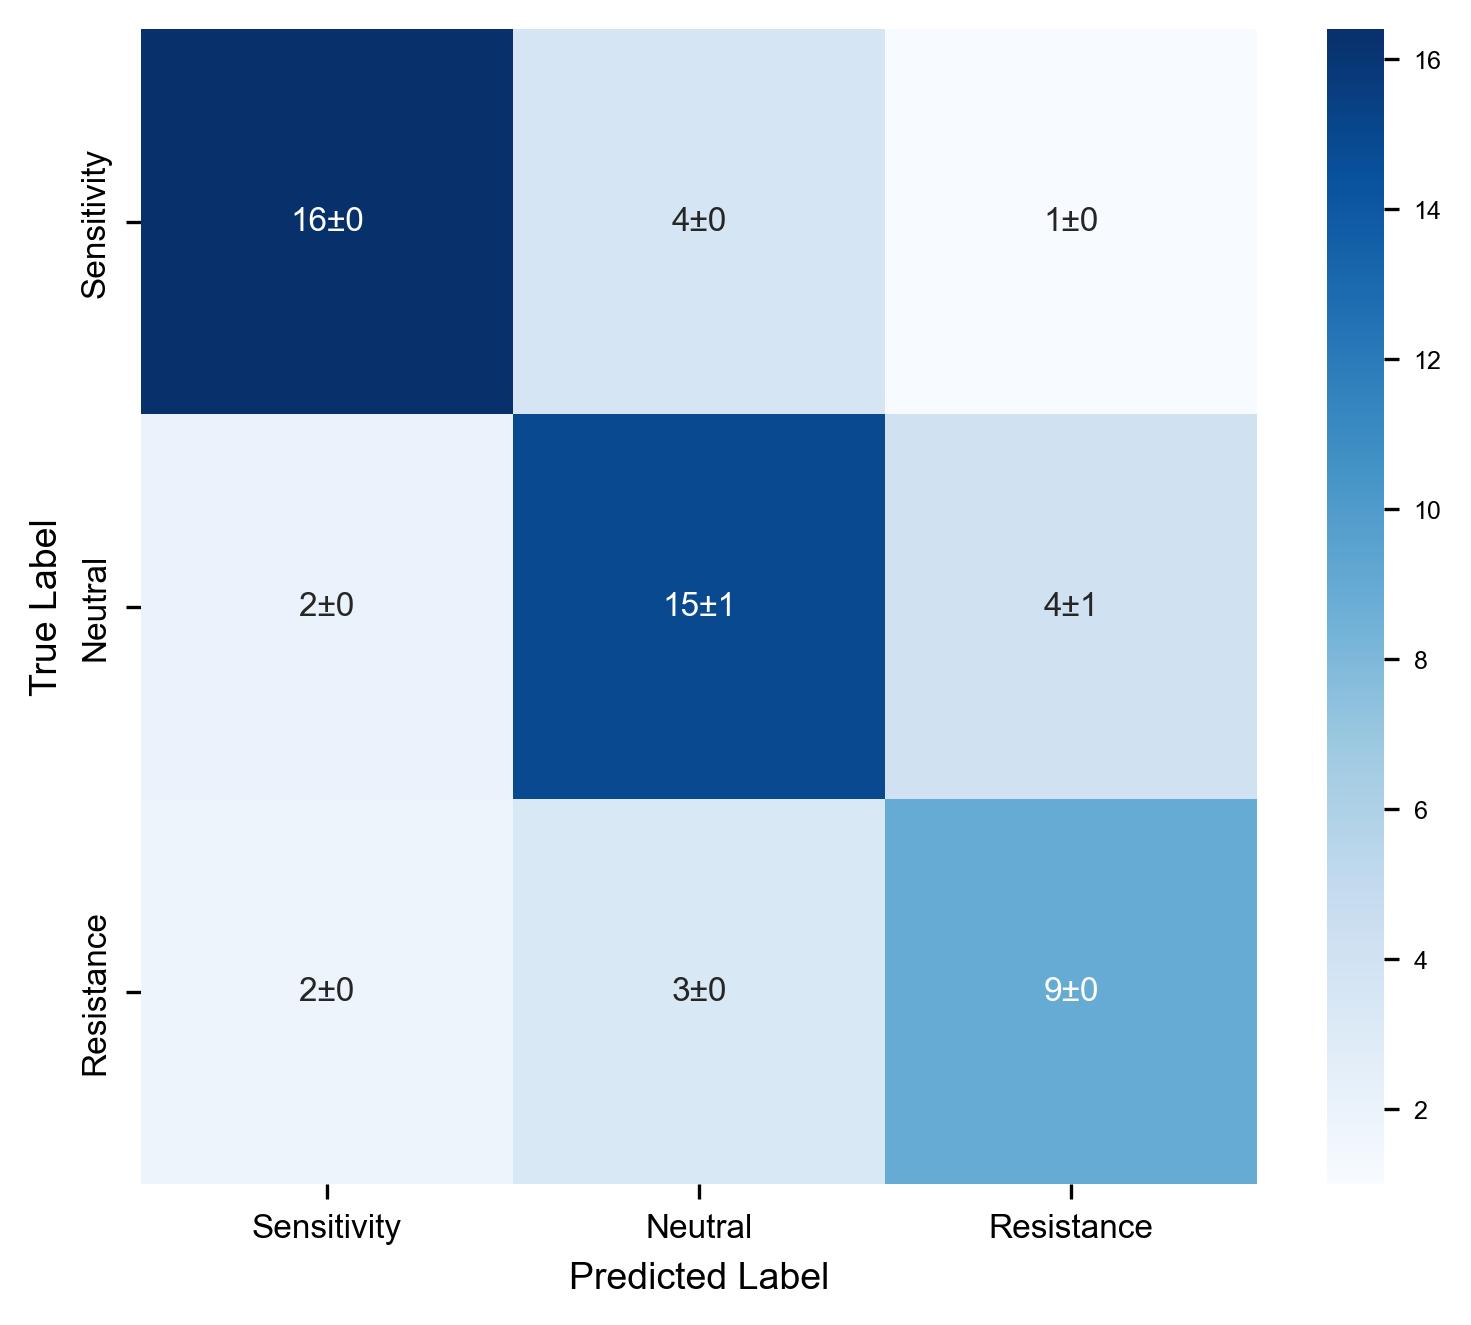

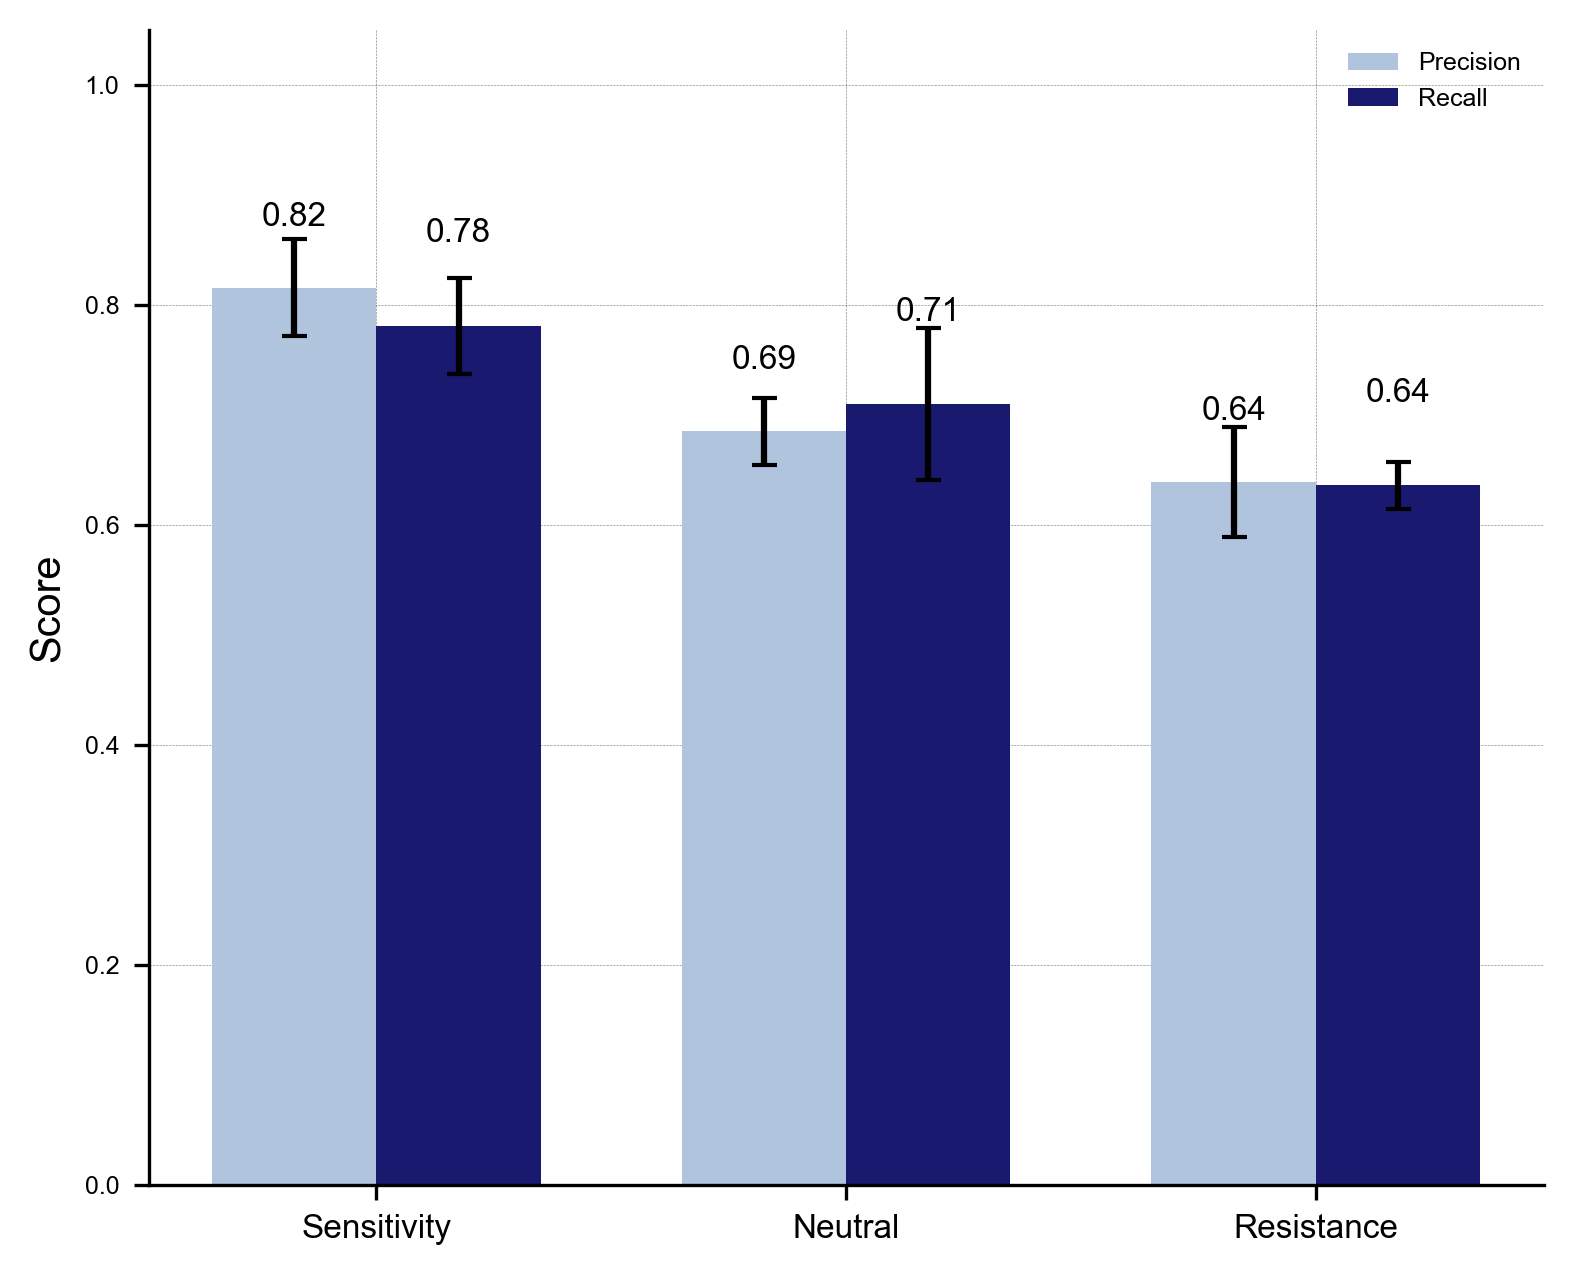

In [44]:
metrics_summary, cm_mean, cm_std = summarize_results(all_metrics, all_cms,
                                                     class_names=le.classes_)

### F1 plot per class

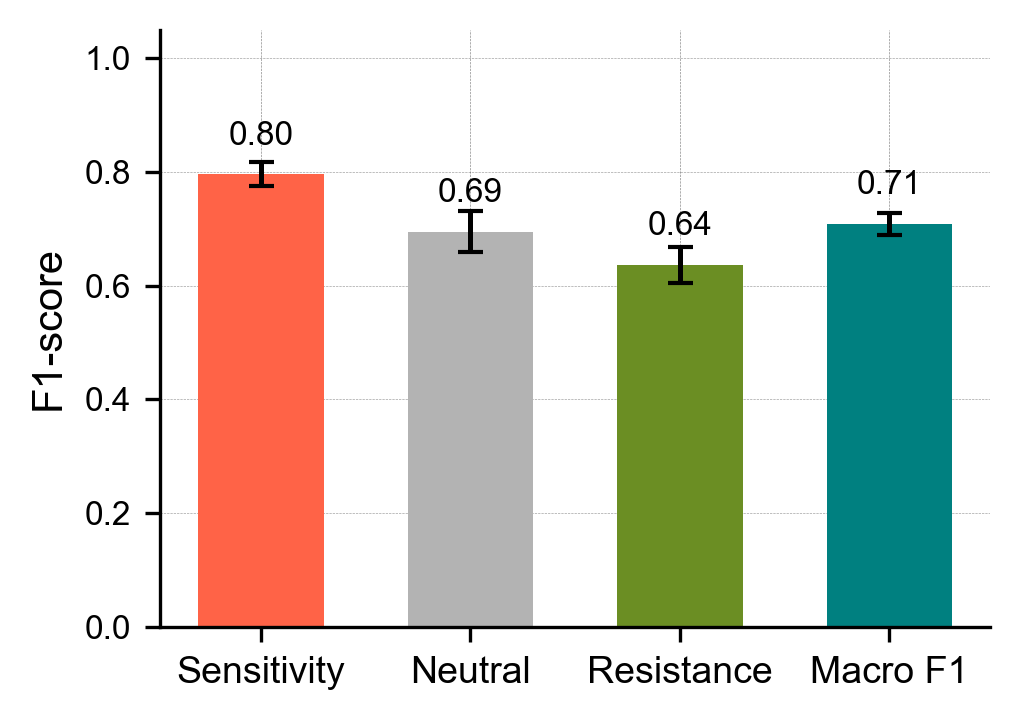

In [45]:
# Define your desired class order (using the metric keys used to index all metrics )
class_order = ["Sensitivity", "Neutral", "Resistance", 'macro avg']

# Display labels for the x-axis
display_labels = ["Sensitivity", "Neutral", "Resistance", "Macro F1"]

# Compute mean and std in that order
f1_means = [np.mean([m[f"f1_{c}"] for m in all_metrics]) for c in class_order]
f1_stds  = [np.std([m[f"f1_{c}"] for m in all_metrics]) for c in class_order]

# Define consistent colors for each class
colors_bar = ["tomato", "#b3b3b3", "olivedrab", "teal"]

x = np.arange(len(display_labels))
plt.figure(figsize=(3.5,2.5))

bars = plt.bar(x, f1_means, yerr=f1_stds, capsize=3, color=colors_bar, width = 0.6, error_kw=dict(ecolor='black', lw=1.2))

# Add value labels
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.04, f"{height:.2f}", ha='center', va='bottom', fontsize=8)

plt.xticks(x, display_labels, fontsize=9)
plt.ylabel("F1-score", fontsize=10)
plt.yticks(fontsize=8)
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
#Save the dataset used for the F1 plot
f1_results_to_plot_df = pd.DataFrame({
    "Class": class_order,
    "F1_mean": f1_means,
    "F1_std": f1_stds
})

f1_results_to_plot_df.to_csv("/Users/carolinapinto/desktop/Tese/Plots/Benchmarking/f1_scores_across_10_runs_plot_benchmark1.csv", index=False)

### PR Curve

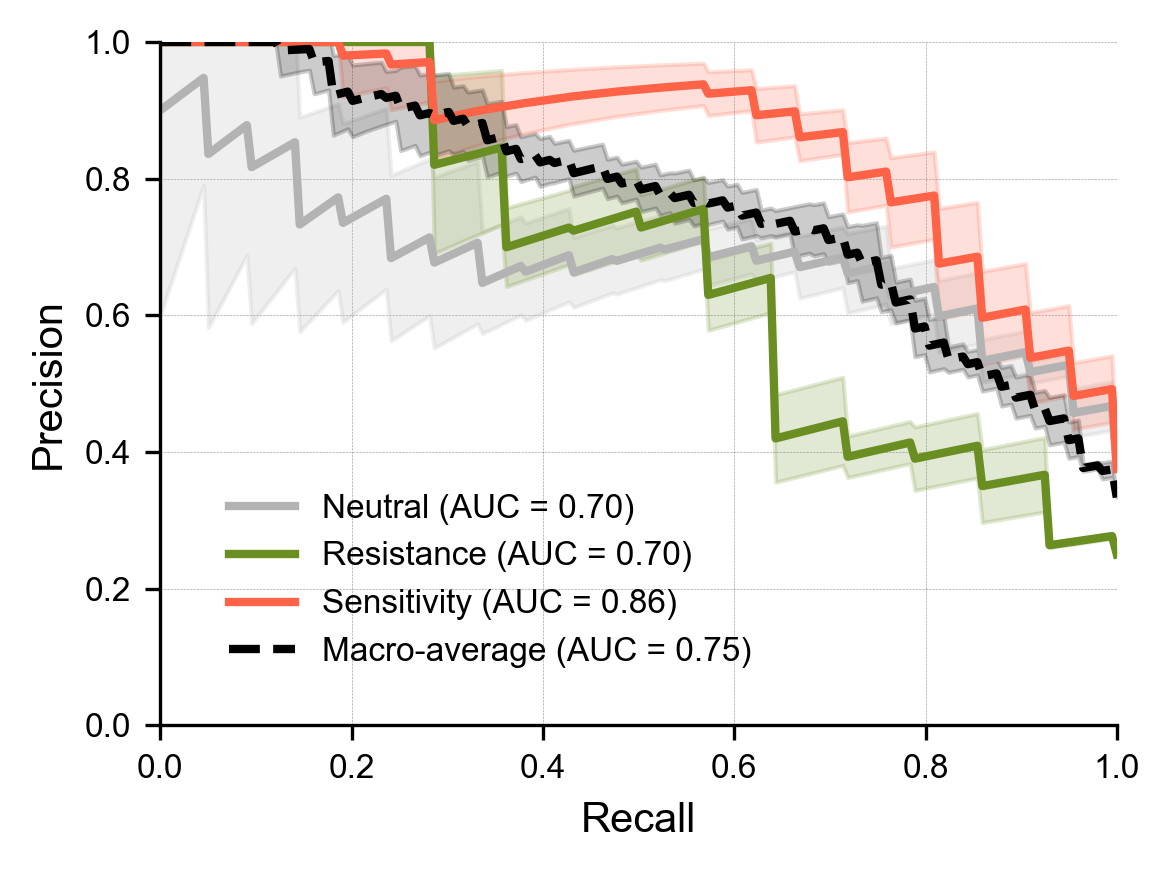

In [47]:
classes_for_binarize = np.arange(len(le.classes_))
colors = ["#b3b3b3", "olivedrab", "tomato"]
recall_grid = np.linspace(0, 1, 200)

plt.figure(figsize=(4,3))

for i, class_name in enumerate(le.classes_):
    precisions_interp = []
    aucs = []
    for y_true, probs in zip(all_y_true_runs, all_probs_runs):
        y_true_bin = label_binarize(y_true, classes=classes_for_binarize)
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], probs[:, i])
        auc = average_precision_score(y_true_bin[:, i], probs[:, i])
        aucs.append(auc)
        precisions_interp.append(np.interp(recall_grid, recall[::-1], precision[::-1]))

    mean_precision = np.mean(precisions_interp, axis=0)
    std_precision  = np.std(precisions_interp, axis=0)
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    plt.plot(recall_grid, mean_precision, color=colors[i], lw=2, label=f"{class_name} (AUC = {mean_auc:.2f})")
    plt.fill_between(recall_grid, mean_precision - std_precision, mean_precision + std_precision,
                     color=colors[i], alpha=0.2)

# Macro-average
macro_precisions = []
macro_aucs = []
for y_true, probs in zip(all_y_true_runs, all_probs_runs):
    y_true_bin = label_binarize(y_true, classes=classes_for_binarize)
    precision, recall, _ = precision_recall_curve(y_true_bin.ravel(), probs.ravel())
    macro_precisions.append(np.interp(recall_grid, recall[::-1], precision[::-1]))
    macro_aucs.append(average_precision_score(y_true_bin, probs, average="macro"))


mean_macro = np.mean(macro_precisions, axis=0)
std_macro = np.std(macro_precisions, axis=0)
mean_auc_macro = np.mean(macro_aucs)
std_auc_macro = np.std(macro_aucs)


plt.plot(recall_grid, mean_macro, color='black', lw=2, linestyle='--', label=f"Macro-average (AUC = {mean_auc_macro:.2f})")
plt.fill_between(recall_grid, mean_macro - std_macro, mean_macro + std_macro, color='black', alpha=0.2)

plt.xlabel("Recall", fontsize=10)
plt.xticks(fontsize=8)
plt.ylabel("Precision", fontsize=10)
plt.yticks(fontsize=8)
#plt.legend(fontsize=6, loc="upper right", frameon=False, bbox_to_anchor=(1.56, 1))
plt.legend(fontsize=8, loc="lower left", frameon=False, bbox_to_anchor=(0.04, 0.04))
plt.grid(alpha=0.4)
plt.ylim(0, 1)
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
#Save PR curve data for reproducibility
classes_for_binarize = np.arange(len(le.classes_))
colors = ["#b3b3b3", "olivedrab", "tomato"]
recall_grid = np.linspace(0, 1, 200)

#Store all PR curves data 
all_pr_dfs = []
for i, class_name in enumerate(le.classes_):
    precisions_interp = []
    aucs = []
    for y_true, probs in zip(all_y_true_runs, all_probs_runs):
        y_true_bin = label_binarize(y_true, classes=classes_for_binarize)
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], probs[:, i])
        auc = average_precision_score(y_true_bin[:, i], probs[:, i])
        aucs.append(auc)
        precisions_interp.append(np.interp(recall_grid, recall[::-1], precision[::-1]))

    mean_precision = np.mean(precisions_interp, axis=0)
    std_precision  = np.std(precisions_interp, axis=0)
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    #Dataframe with the per-class PR curve data for reproducibility
    df_class = pd.DataFrame({
        "Recall": recall_grid,
        "Mean_Precision": mean_precision,
        "Std_Precision": std_precision,
        "Class": class_name,
        "Mean_AUC": mean_auc,
        "Std_AUC": std_auc
    })
    all_pr_dfs.append(df_class)

# Macro-average
macro_precisions = []
macro_aucs = []
for y_true, probs in zip(all_y_true_runs, all_probs_runs):
    y_true_bin = label_binarize(y_true, classes=classes_for_binarize)
    precision, recall, _ = precision_recall_curve(y_true_bin.ravel(), probs.ravel())
    macro_precisions.append(np.interp(recall_grid, recall[::-1], precision[::-1]))
    macro_aucs.append(average_precision_score(y_true_bin, probs, average="macro"))


mean_macro = np.mean(macro_precisions, axis=0)
std_macro = np.std(macro_precisions, axis=0)
mean_auc_macro = np.mean(macro_aucs)
std_auc_macro = np.std(macro_aucs)

df_macro = pd.DataFrame({
    "Recall": recall_grid,
    "Mean_Precision": mean_macro,
    "Std_Precision": std_macro,
    "Class": "Macro-average",
    "Mean_AUC": mean_auc_macro,
    "Std_AUC": std_auc_macro
})
all_pr_dfs.append(df_macro)

#Combine all into a single dataframe
pr_curve_data_df = pd.concat(all_pr_dfs, ignore_index=True)
pr_curve_data_df.to_csv("/Users/carolinapinto/desktop/Tese/Plots/Benchmarking/pr_curve_data_across_10_runs_plot_benchmark1.csv", index=False)

## Recall Plot

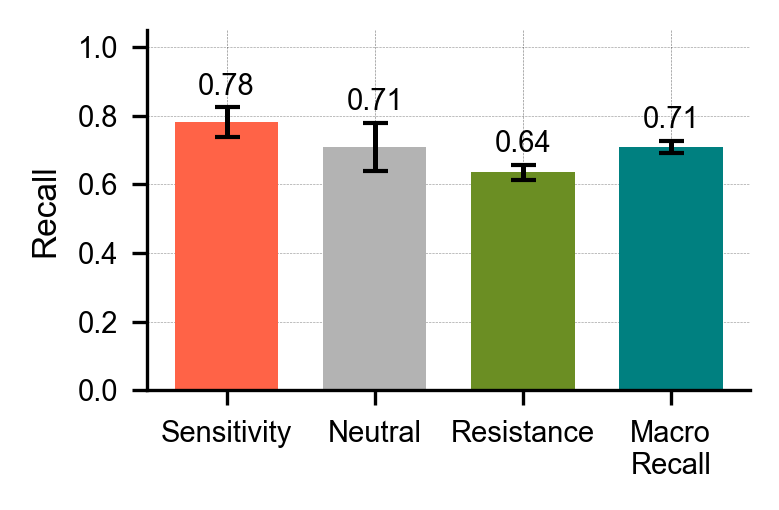

In [69]:
class_order = ["Sensitivity", "Neutral", "Resistance", 'macro avg']

# Display labels for the x-axis
display_labels = ["Sensitivity", "Neutral", "Resistance", "Macro\nRecall"]

# Compute mean and std in that order
recall_means = [np.mean([m[f"recall_{c}"] for m in all_metrics]) for c in class_order]
recall_stds  = [np.std([m[f"recall_{c}"] for m in all_metrics]) for c in class_order]

# Define consistent colors for each class
colors_bar = ["tomato", "#b3b3b3", "olivedrab", "teal"]

x = np.arange(len(display_labels))
plt.figure(figsize=(2.7,1.8))

bars = plt.bar(x, recall_means, yerr=recall_stds, capsize=3, color=colors_bar, width = 0.7, error_kw=dict(ecolor='black', lw=1.2))

# Add value labels
#for i, bar in enumerate(bars):
    #height = bar.get_height()
    #plt.text(bar.get_x() + bar.get_width()/2, height + 0.075, f"{height:.2f}", ha='center', va='bottom', fontsize=8)

for i, bar in enumerate(bars):
    mean = recall_means[i]
    std = recall_stds[i]

    plt.text(bar.get_x() + bar.get_width()/2,
             mean + std + 0.02,
             f"{mean:.2f}",
             ha='center', va='bottom', fontsize=7)

plt.xticks(x, display_labels, fontsize=7)
plt.ylabel("Recall", fontsize=8)
plt.yticks(fontsize=7)
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## SHAP

Train the model on EG and compute SHAP on MC

In [52]:
#Prepare X and y
X_train= annotated_variants_EG_balanced.drop(columns=meta_cols + ["Class_encoded"])
y_train= annotated_variants_EG_balanced["Class_encoded"]
meta_data_train = annotated_variants_EG_balanced[meta_cols]

X_test = annotated_variants_MC_balanced.drop(columns=meta_cols + ["Class_encoded"])
y_test = annotated_variants_MC_balanced["Class_encoded"]
meta_data_test = annotated_variants_MC_balanced[meta_cols]


#Train final model on the entire balanced dataset
final_model = XGBClassifier(**optimized_params)
final_model.fit(X_train, y_train)

#Predict y (for shap UMAP with predicted class)
y_pred_final = final_model.predict(X_test)

#Compute SHAP values 
explainer = shap.TreeExplainer(final_model, X_train)
shap_values_EG = explainer.shap_values(X_train)
shap_values_MC = explainer.shap_values(X_test)

100%|===================| 6069/6081 [05:27<00:00]        

In [53]:
print(type(shap_values_MC))
print(np.array(shap_values_MC).shape)

<class 'numpy.ndarray'>
(56, 68, 3)


In [54]:
print(type(shap_values_EG))
print(np.array(shap_values_EG).shape)

<class 'numpy.ndarray'>
(2027, 68, 3)


In [55]:
def get_stacked_shap_for_class(shap_values, X, le, target_class):
    
    class_idx = list(le.classes_).index(target_class)
    shap_c = shap_values[:, :, class_idx]

    assert shap_c.shape[0] == X.shape[0], "Row mismatch after stacking"
    return shap_c, X

def top_k_features_by_mean_abs_shap(shap_c, X, k=10):
    mean_abs = np.mean(np.abs(shap_c), axis=0)
    s = pd.Series(mean_abs, index=X.columns).sort_values(ascending=False)
    return s.head(k)  #Series: index=feature, value=mean|SHAP|


def plot_topk_shap_for_class(all_shap_values_runs, all_X_val_runs, le, target_class, k=10):
    shap_c, X = get_stacked_shap_for_class(all_shap_values_runs, all_X_val_runs, le, target_class)

    topk = top_k_features_by_mean_abs_shap(shap_c, X, k=k)
    top_features = topk.index.tolist()

    # Subset to top-k features
    cols_idx = [X.columns.get_loc(f) for f in top_features]
    shap_top = shap_c[:, cols_idx]
    X_top = X[top_features]

    print(f"\n=== {target_class}: Top {k} by mean(|SHAP|) ===")
    print(topk)


    # Bar: mean absolute SHAP
    shap.summary_plot(shap_top, X_top, plot_type="bar", max_display=k, plot_size=(6, 2), show=False)
    plt.xlabel("Mean |SHAP value|", fontsize=10)
    plt.xticks(fontsize=9)
    plt.yticks(fontsize=9)
    plt.tight_layout()
    plt.show()

    # Beeswarm: distribution + direction
    shap.summary_plot(shap_top, X_top, max_display=k, plot_size=(6, 3), show=False)
    plt.xlabel("SHAP value", fontsize=12)
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)
    #plt.xlim(-1, 1)

    fig = plt.gcf()
    axes = fig.axes

    # The last axis is the colorbar
    cbar_ax = axes[-1]

    # Change tick label size (Low / High numbers if present)
    cbar_ax.tick_params(labelsize=10)

    # Change colorbar label size
    cbar_ax.set_ylabel("Feature value", fontsize=11)

    plt.tight_layout()
    plt.show()


=== Sensitivity: Top 5 by mean(|SHAP|) ===
lnIC50                       0.280192
CRISPR_essentiality_score    0.253419
protein_abundance_zscore     0.248403
Gene_expression_voom         0.147723
LOEUF                        0.122805
dtype: float64


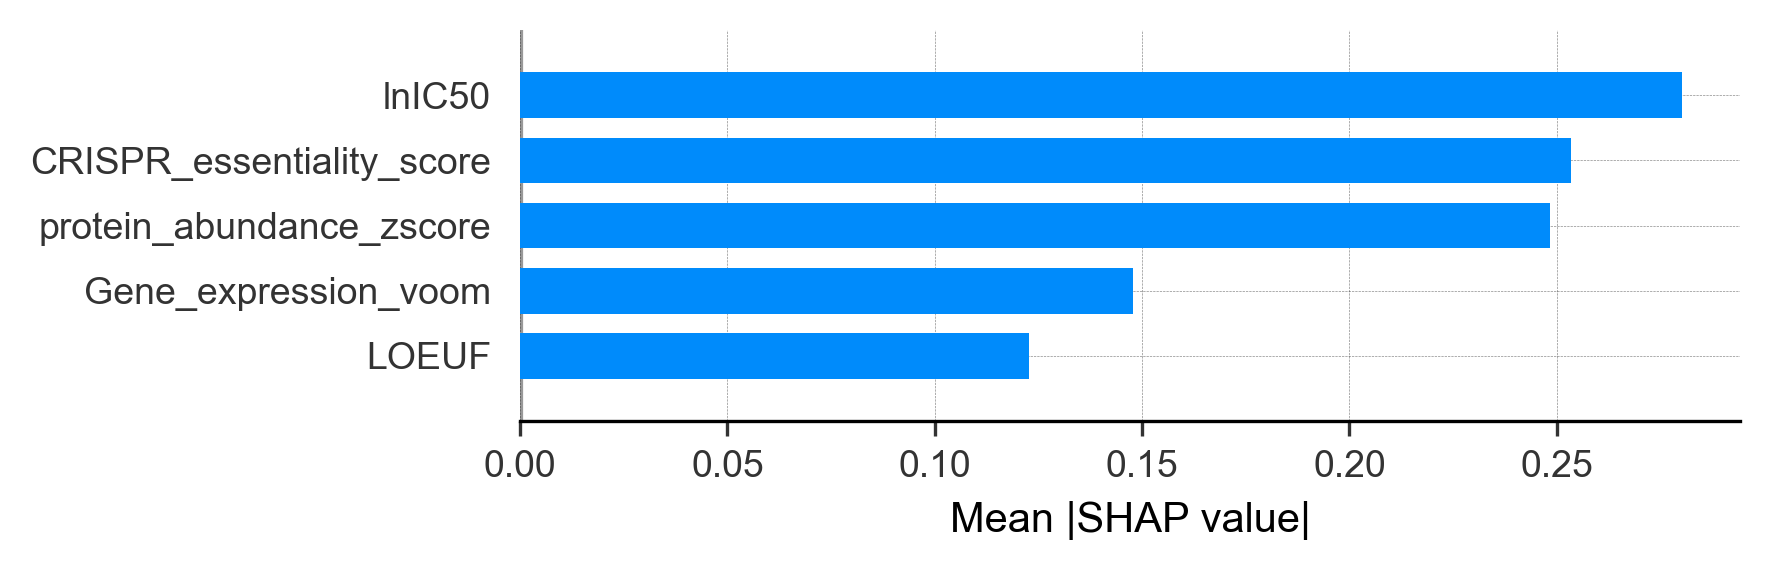

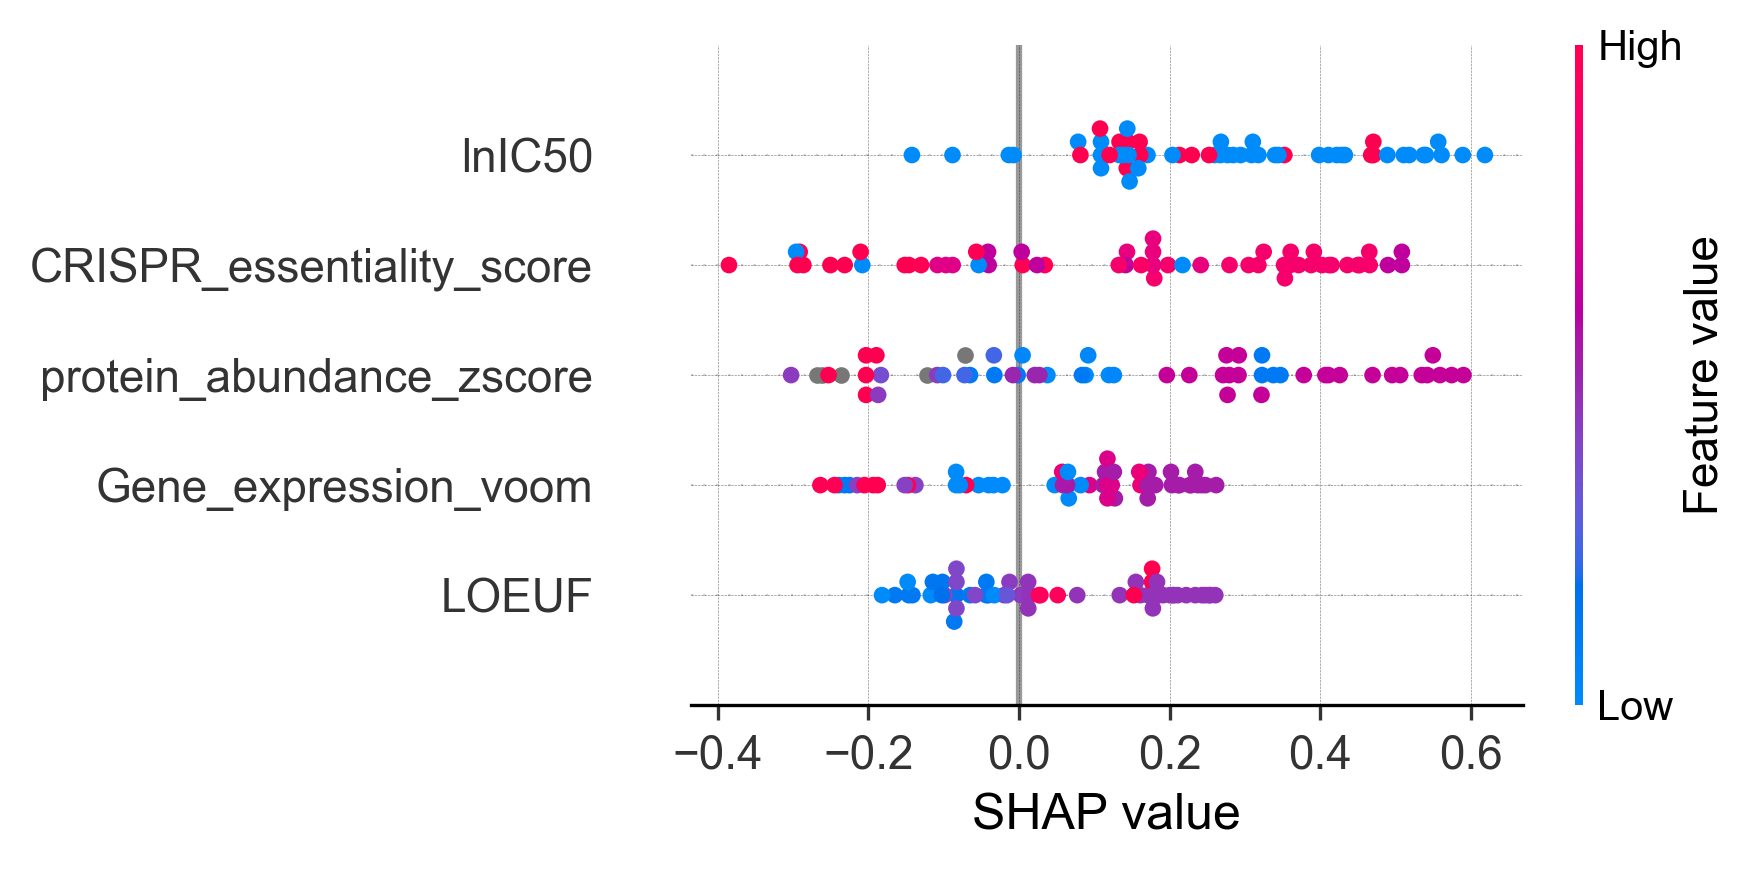

In [56]:
plot_topk_shap_for_class(shap_values_MC, X_test, le, target_class='Sensitivity', k=5)


=== Neutral: Top 5 by mean(|SHAP|) ===
lnIC50                       0.279224
CADD_PHRED                   0.207426
CRISPR_essentiality_score    0.173486
BayesDel_noAF_score          0.083398
SpliceAI_pred_DP_AL          0.056277
dtype: float64


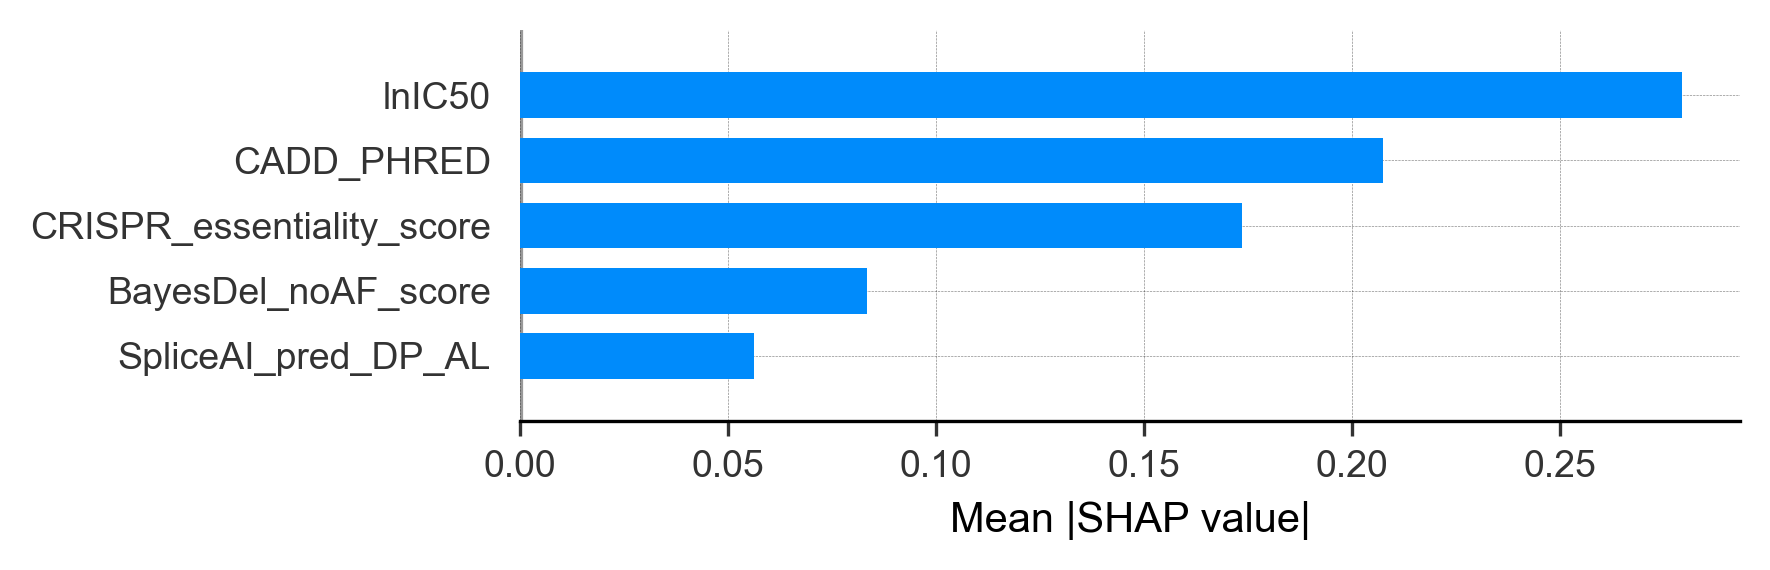

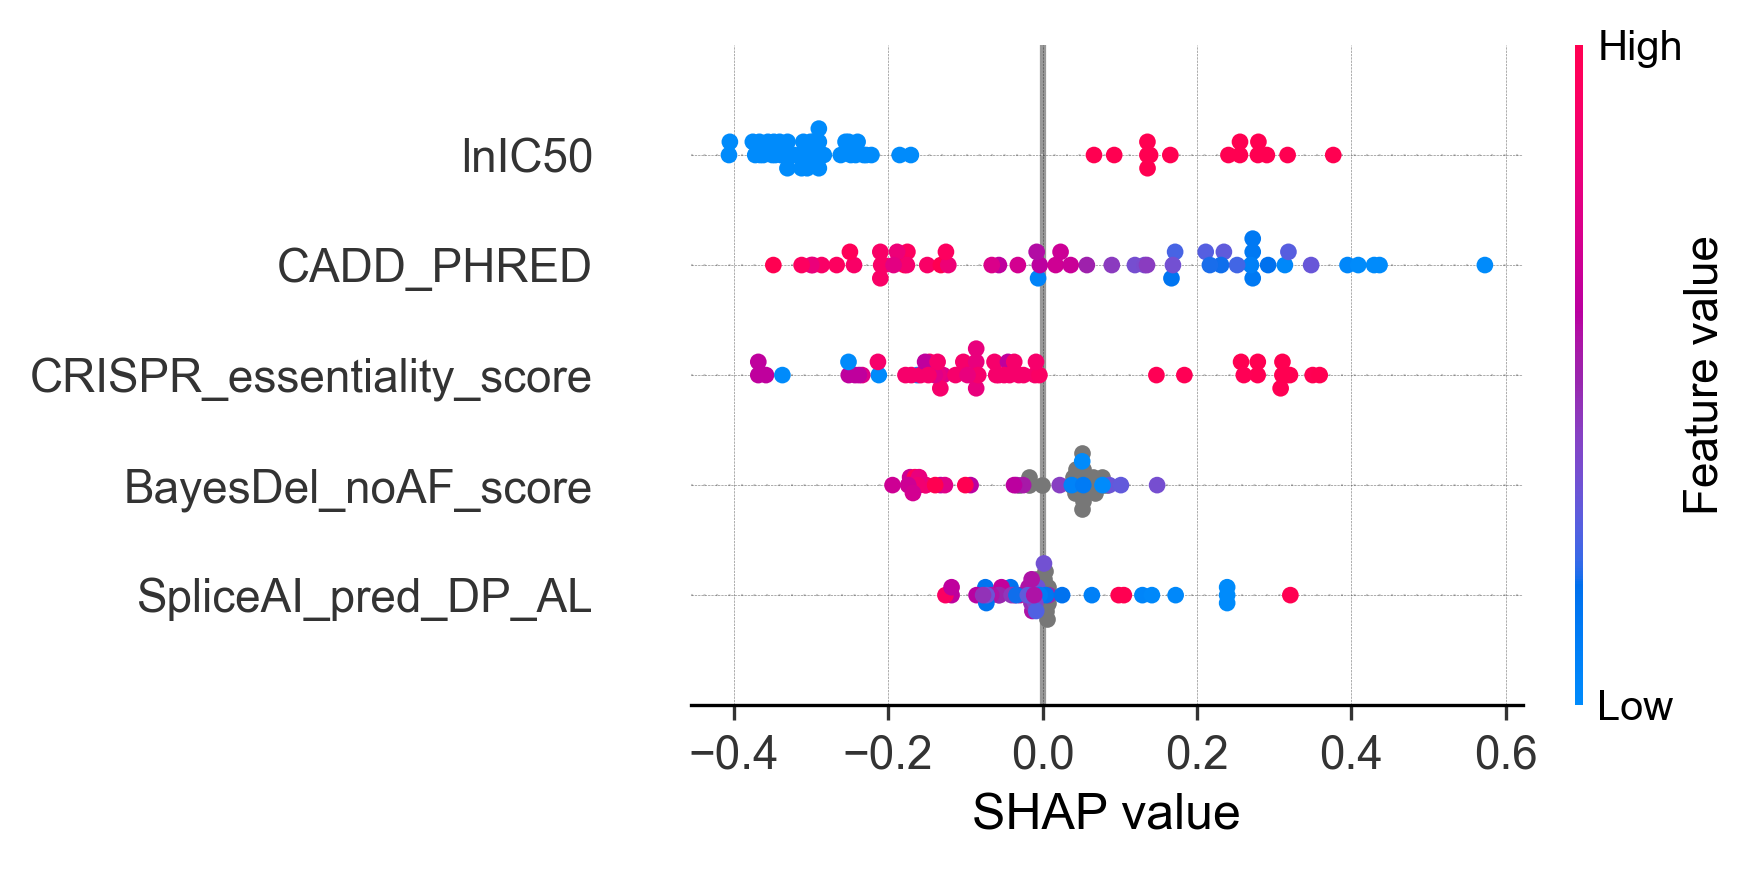

In [57]:
plot_topk_shap_for_class(shap_values_MC, X_test, le, target_class='Neutral', k=5)


=== Resistance: Top 5 by mean(|SHAP|) ===
protein_abundance_zscore     0.199464
lnIC50                       0.143969
CRISPR_essentiality_score    0.115283
LOEUF                        0.093488
gene_cn_total                0.078190
dtype: float64


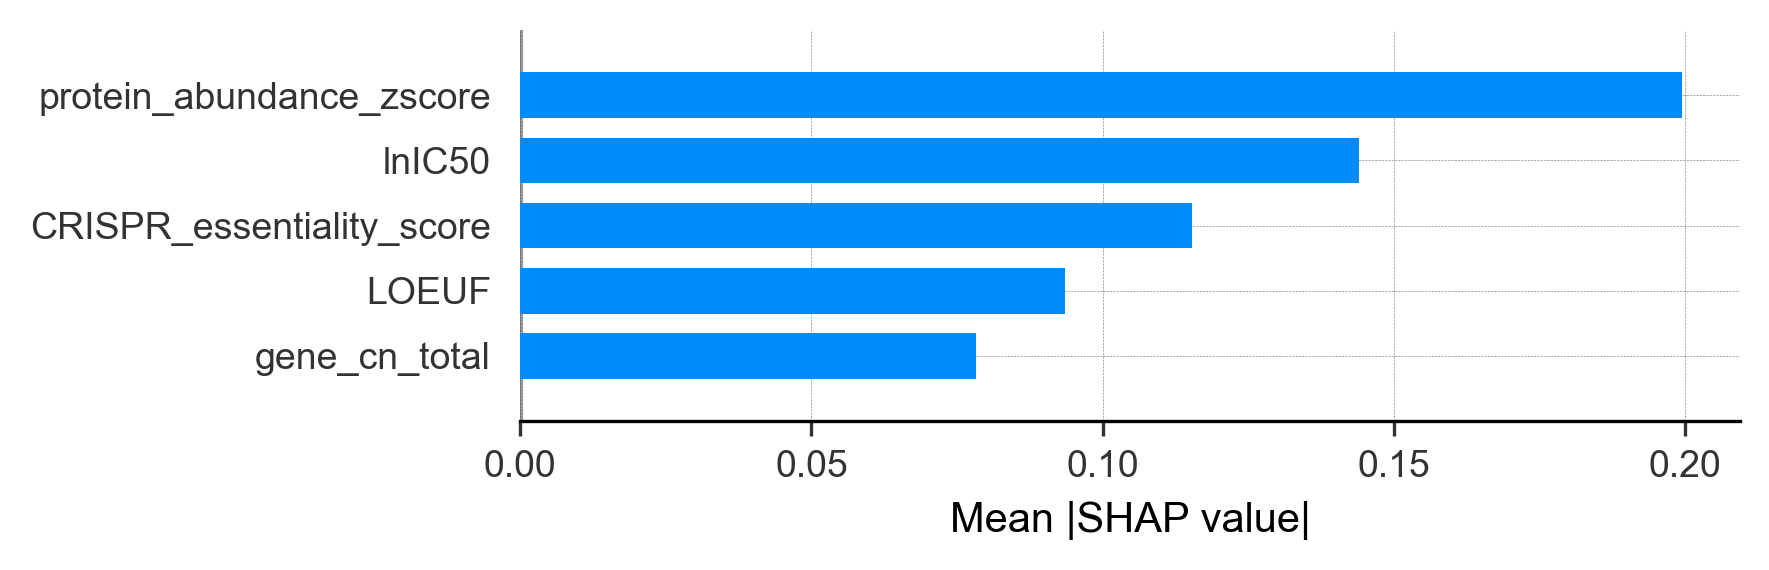

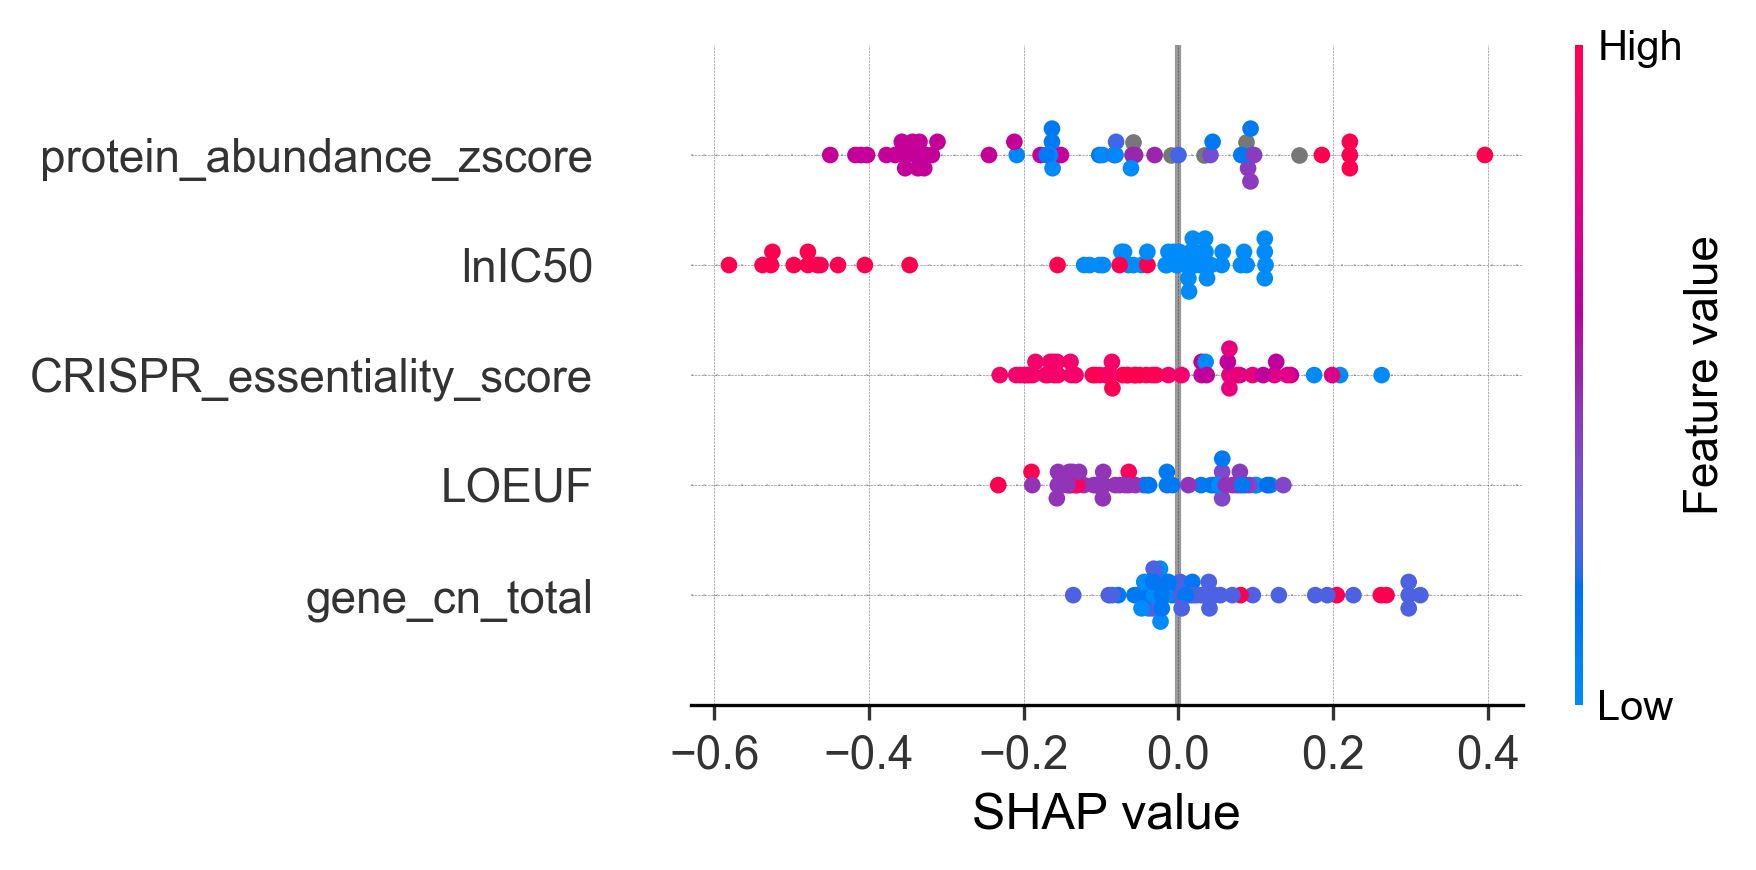

In [41]:
plot_topk_shap_for_class(shap_values_MC, X_test, le, target_class='Resistance', k=5)

### SHAP UMAP

In [58]:
def get_shap_predicted_class(shap_values, y_pred):
    """
    Get SHAP values corresponding to the predicted class for each sample.
    """
    assert shap_values.shape[0] == len(y_pred)
    return shap_values[np.arange(len(y_pred)), :, y_pred]

def fit_shap_umap(shap_matrix, scale=True):
    if scale:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(shap_matrix)

    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        n_components=2,
        random_state=42
    )

    reducer.fit(X_scaled)
    return reducer, scaler

def transform_shap_umap(shap_matrix, reducer, scaler):
    X_scaled = scaler.transform(shap_matrix)
    return reducer.transform(X_scaled)

def plot_umap(embedding, color=None, cmap="viridis"):
    plt.figure(figsize=(6, 5))
    plt.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=color,
        cmap=cmap,
        s=6,
        alpha=0.7
    )
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.tight_layout()
    plt.show()

In [59]:
#SHAP per class
idx_sensitivity = list(le.classes_).index("Sensitivity")
idx_neutral = list(le.classes_).index("Neutral")
idx_resistance = list(le.classes_).index("Resistance")

shap_sensitivity_MC = shap_values_MC[:, :, idx_sensitivity]
shap_neutral_MC = shap_values_MC[:, :, idx_neutral]
shap_resistance_MC = shap_values_MC[:, :, idx_resistance]

shap_sensitivity_EG = shap_values_EG[:, :, idx_sensitivity]
shap_neutral_EG = shap_values_EG[:, :, idx_neutral]
shap_resistance_EG = shap_values_EG[:, :, idx_resistance]

In [60]:
shap_concat_MC = np.concatenate([shap_sensitivity_MC, shap_neutral_MC, shap_resistance_MC], axis=1)
shap_concat_EG = np.concatenate([shap_sensitivity_EG, shap_neutral_EG, shap_resistance_EG], axis=1)


In [61]:
shap_sensitivity_MC.shape, shap_neutral_MC.shape, shap_resistance_MC.shape, shap_concat_MC.shape

((56, 68), (56, 68), (56, 68), (56, 204))

In [62]:
shap_sensitivity_EG.shape, shap_neutral_EG.shape, shap_resistance_EG.shape, shap_concat_EG.shape

((2027, 68), (2027, 68), (2027, 68), (2027, 204))

In [63]:
#Get UMAP embedding of SHAP values
#Fit on EG
reducer, scaler = fit_shap_umap(shap_concat_EG)

# Embed EG
embed_EG = transform_shap_umap(shap_concat_EG, reducer, scaler)

# Embed MC
embed_MC = transform_shap_umap(shap_concat_MC, reducer, scaler)

/Users/carolinapinto/Desktop/Tese/BECancerResistome/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


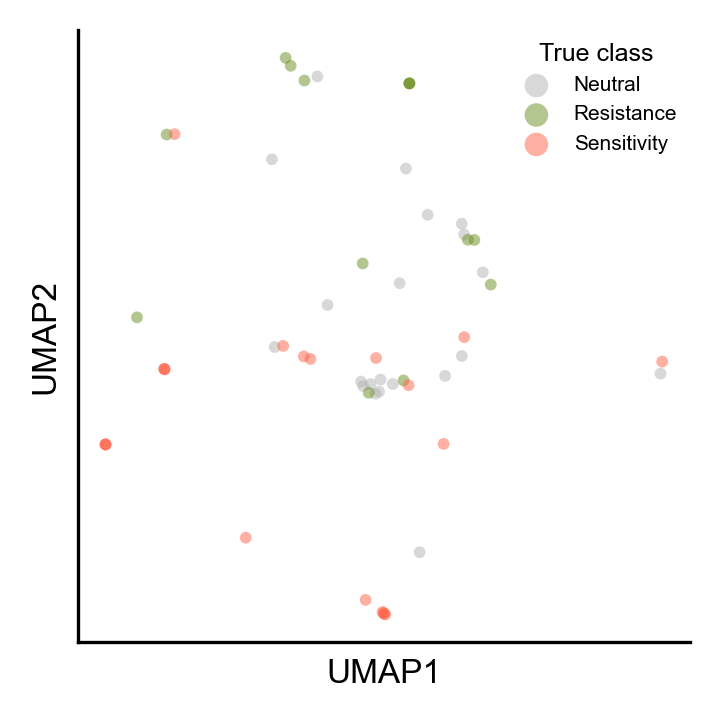

In [69]:
# UMAP colored by true class
class_labels = {i: c for i, c in enumerate(le.classes_)}
class_colors = {
    0: "#b3b3b3",
    1: "olivedrab",
    2: "tomato",
}

plt.figure(figsize=(2.5, 2.5))

for class_idx in np.unique(y_test):
    mask = y_test == class_idx

    plt.scatter(
        embed_MC[mask, 0],
        embed_MC[mask, 1],
        c=class_colors[class_idx],
        label=class_labels[class_idx],
        s=8,
        alpha=0.5,
        edgecolors='none',
        linewidths=0
    )

plt.xlabel("UMAP1", fontsize=8)

plt.ylabel("UMAP2", fontsize=8)
plt.xticks([])
plt.yticks([])
plt.tick_params(left=False, bottom=False)
plt.legend(title="True class", markerscale=2, fontsize=5, title_fontsize=6, loc="upper right", frameon=False, bbox_to_anchor=(1.01, 1.01))
plt.grid(False)
plt.tight_layout()
plt.show()

In [70]:
# UMAP colored by drug

drugs = meta_data_test["Drug"].values

# Sanity check
assert len(drugs) == embed_MC.shape[0]

# Define labels and colors 
unique_drug = np.unique(drugs)

drug_colors = {
    unique_drug[0]: "#0072B2",
    unique_drug[1]: "#E69F00",
    unique_drug[2]: "#009E73",
}

plt.figure(figsize=(4, 2.5))

for drug in unique_drug:
    mask = drugs == drug
    plt.scatter(
        embed_MC[mask, 0],
        embed_MC[mask, 1],
        c=drug_colors[drug],
        label=drug,
        s=8,
        alpha=0.5,
        edgecolors='none',
        linewidths=0 
    )

plt.xlabel("UMAP1", fontsize=8)
plt.ylabel("UMAP2", fontsize=8)
plt.xticks([])
plt.yticks([])
plt.tick_params(left=False, bottom=False)
plt.legend(title="Drug", markerscale=2, fontsize=6, title_fontsize=7, loc="upper left", frameon=False, bbox_to_anchor=(0.02, 1))
plt.tight_layout()
plt.show()

IndexError: index 2 is out of bounds for axis 0 with size 2